In [1]:
from tmu.models.classification.vanilla_classifier import TMClassifier
import numpy as np
import os 
import logging
import config
import pickle
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_adaptive_gaussian_thresholding_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, build_save_path, load_raw_maps_and_plot_heatmap

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-10 21:19:52,631 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-05-10 21:19:52,637 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-05-10 21:19:52,650 - matplotlib - DEBUG - interactive is False
2026-05-10 21:19:52,651 - matplotlib - DEBUG - platform is linux
2026-05-10 21:19:52,703 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-05-10 21:19:52,705 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.ADAPTIVE_GAUSSIAN
CURRENT_DATASET = config.BLOODMNIST
CURRENT_RESOLUTION = 1 
specialist_name = "Adaptive Gaussian"
channel_names = [f"{specialist_name} - {c}" for c in ["Red", "Green", "Blue"]]



In [3]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [4]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_adaptive_gaussian_thresholding_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test)

In [5]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_val  = Y_val.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)

In [6]:
study = run_tm_optuna_search(
    TMClassifier,
    config,
    X_train,
    Y_train,
    X_val,
    Y_val,
    metric="f1_macro",
)

[I 2026-04-06 19:36:55,338] A new study created in memory with name: no-name-af585ccd-d548-46fe-b7bd-64ef7aaba5aa
[W 2026-04-06 19:37:04,375] Trial 0 failed with parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/coder/masters_thesis/venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/home/coder/masters_thesis/utils/optuna.py", line 129, in objective
    tm_trial.fit(X_train, Y_train, epochs=1, incremental=True)
  File "/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tmu/models/classification/vanilla_classifier.py", line 403, in fit
    history: dict = self._fit_sample(
                    ^^^^^^^^^^^^^^^^^
  File "/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tmu/models/classification/vanilla_classifier.py", line 351, 

KeyboardInterrupt: 

In [6]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/adaptive_gaussian.json")

NameError: name 'study' is not defined

In [6]:
best_value, best_params = load_optuna_best_results("hyperparameters/adaptive_gaussian.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [9]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="BloodMNIST_Adaptive_Gaussian",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 71.47% (553.37s)


#2 Accuracy: 75.65% (484.65s)


#3 Accuracy: 77.49% (463.81s)


#4 Accuracy: 77.67% (449.93s)


...

#96 Accuracy: 84.74% (363.27s)


#97 Accuracy: 84.57% (363.02s)


#98 Accuracy: 84.68% (362.70s)


#99 Accuracy: 84.83% (360.92s)


#100 Accuracy: 84.30% (361.50s)


In [7]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "BloodMNIST_Adaptive_Gaussian_Specialist.pkl")

In [11]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [8]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

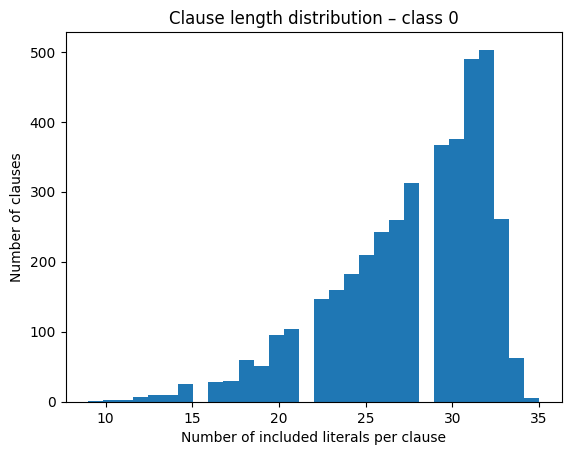

Class 0: median=29.0, mean=27.6, std=4.4


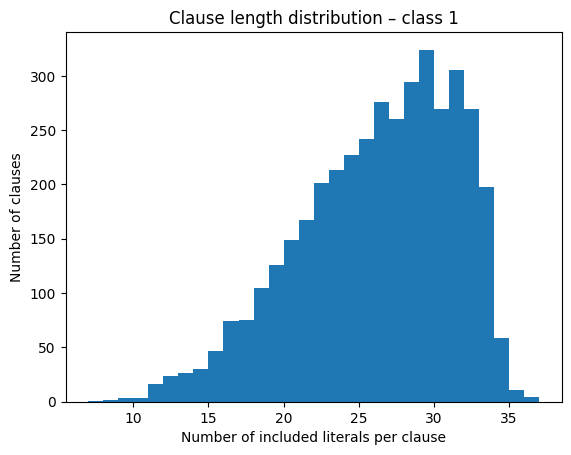

Class 1: median=26.0, mean=25.8, std=5.2


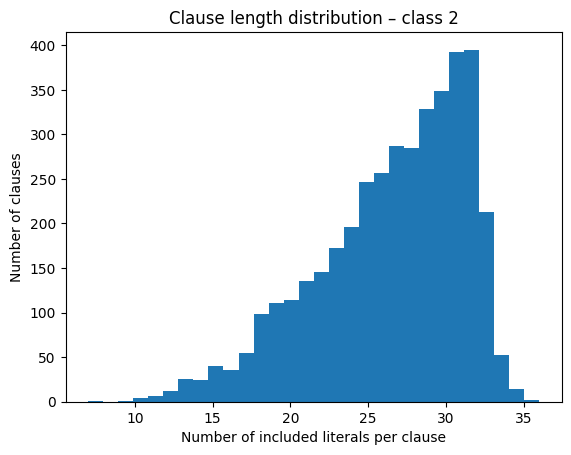

Class 2: median=28.0, mean=26.7, std=4.9


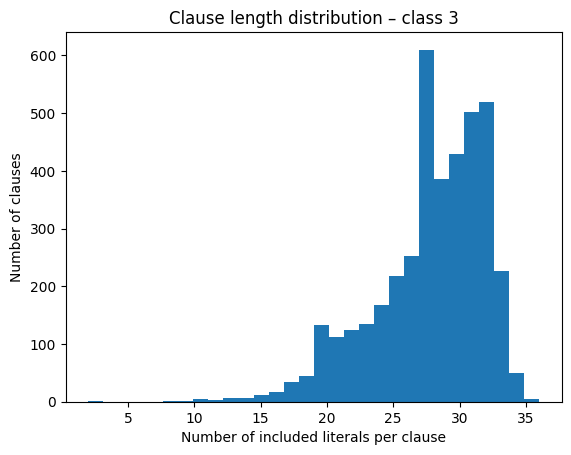

Class 3: median=29.0, mean=27.8, std=4.2


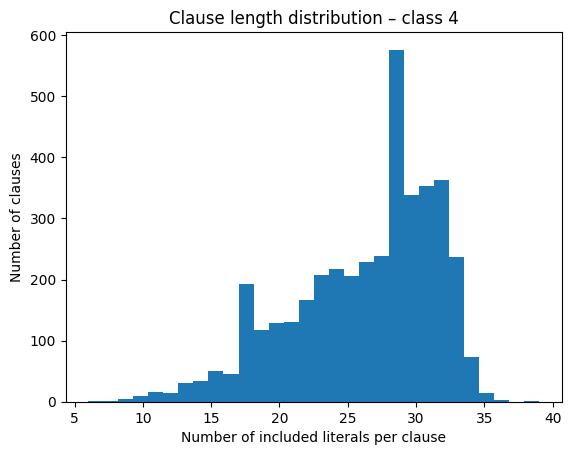

Class 4: median=27.0, mean=26.3, std=5.3


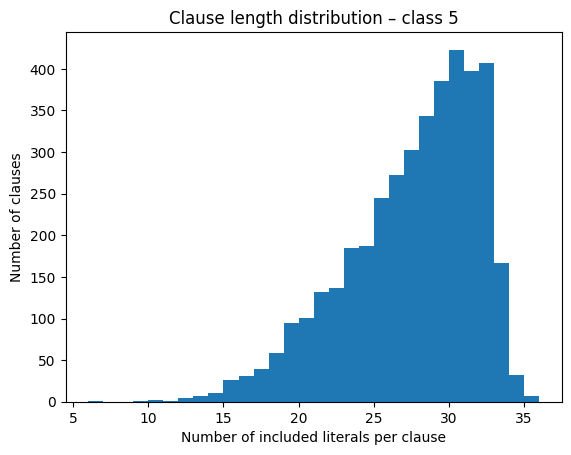

Class 5: median=28.0, mean=27.1, std=4.4


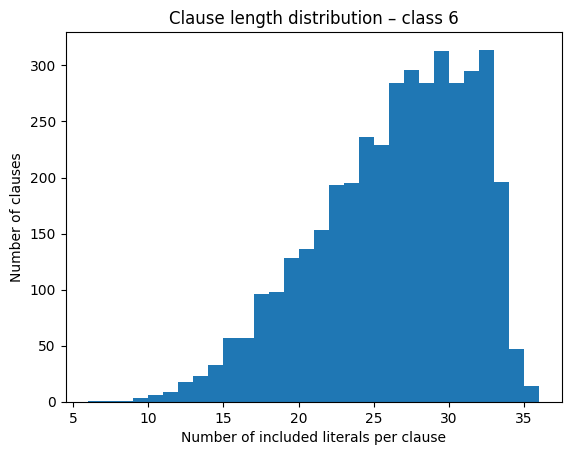

Class 6: median=27.0, mean=25.9, std=5.2


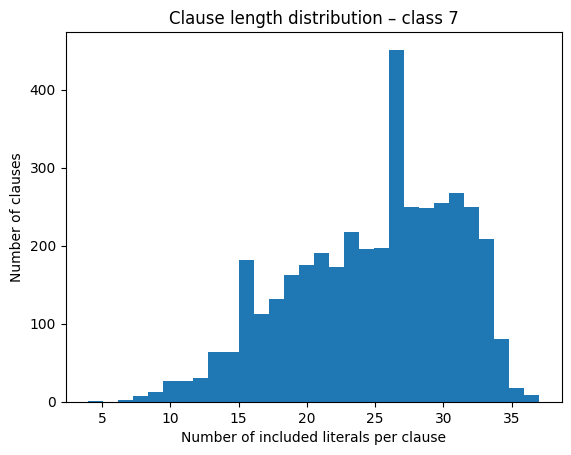

Class 7: median=26.0, mean=24.9, std=6.0


In [14]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 84.30%
2026-05-10 21:20:13,772 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 21:20:13,774 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 21:20:13,796 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x75ab72b81160>


Saved to saved_confusion_matrices/blood_adaptive_gaussian.svg


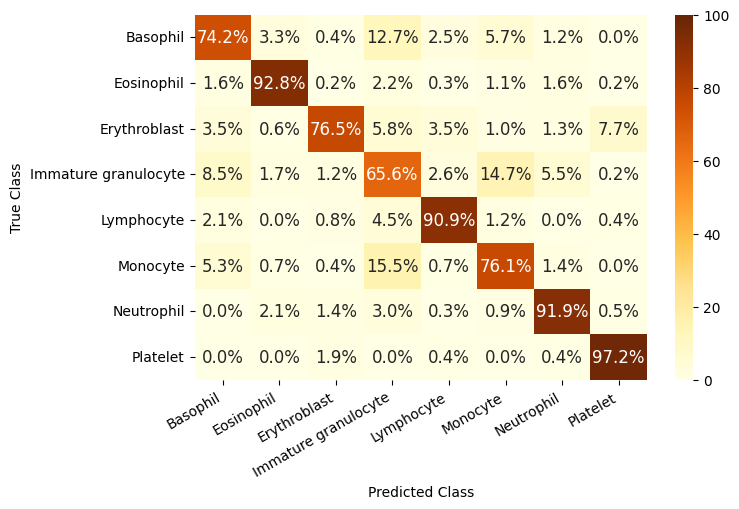

In [9]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="BloodMNIST_Adaptive_Gaussian", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, rotate_xlabels=True, figsize=(7.8, 5.2), cmap = "YlOrBr") 

# Class 0 Local Examples 

In [9]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

0
2026-04-15 11:33:13,769 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-15 11:33:13,775 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 384  |  predicted class: 0
2026-04-15 11:33:13,814 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a80364d70>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c0_s384_aggr.svg


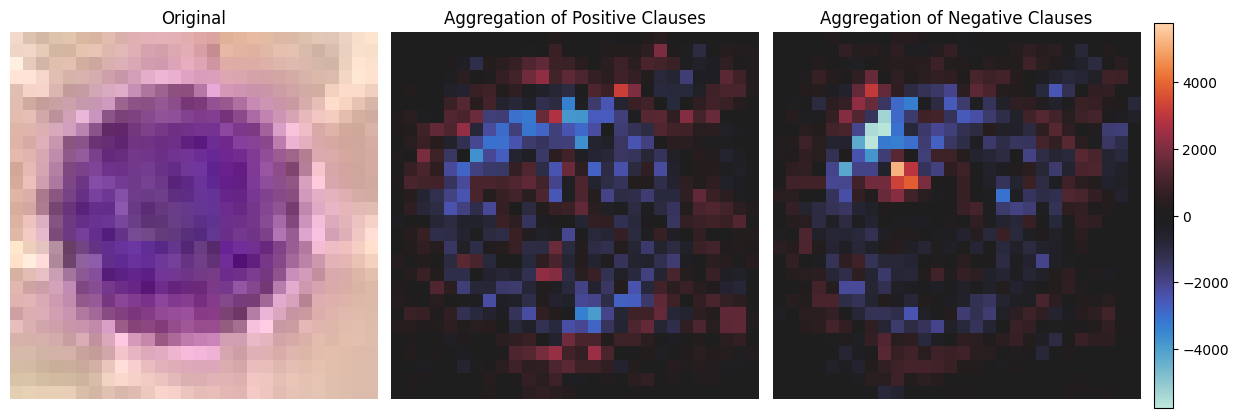

Visualizing sample 384  |  predicted class: 0
2026-04-15 11:33:17,451 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a80095af0>
2026-04-15 11:33:17,635 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a80366e40>
2026-04-15 11:33:17,663 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a81066540>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c0_s384_chan.svg


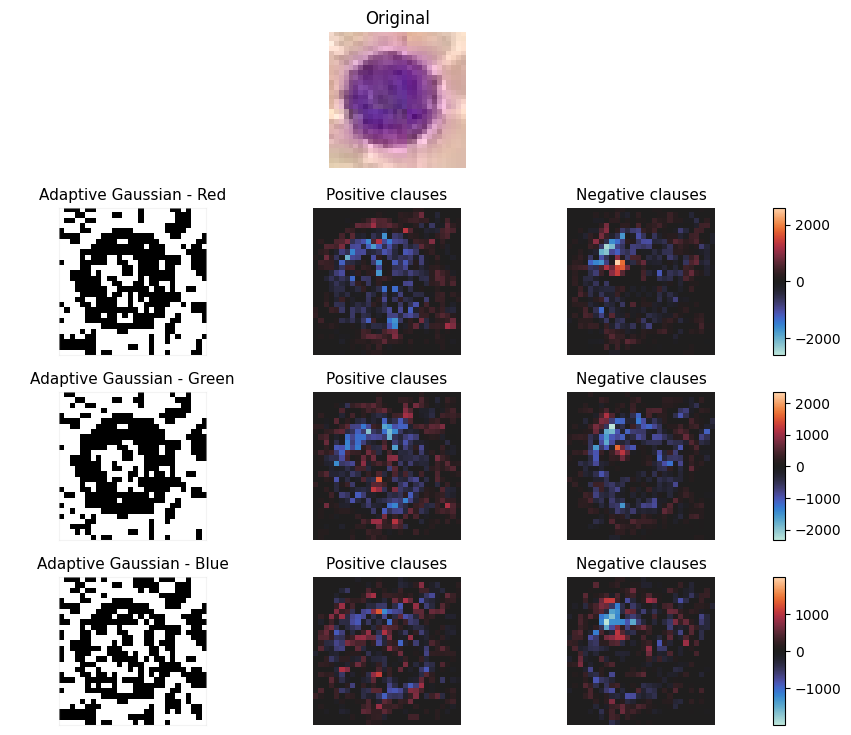

In [9]:
image_index =  384

target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

0
Visualizing sample 1521  |  predicted class: 0
2026-04-15 11:33:33,316 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a62cebad0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c0_s1521_aggr.svg


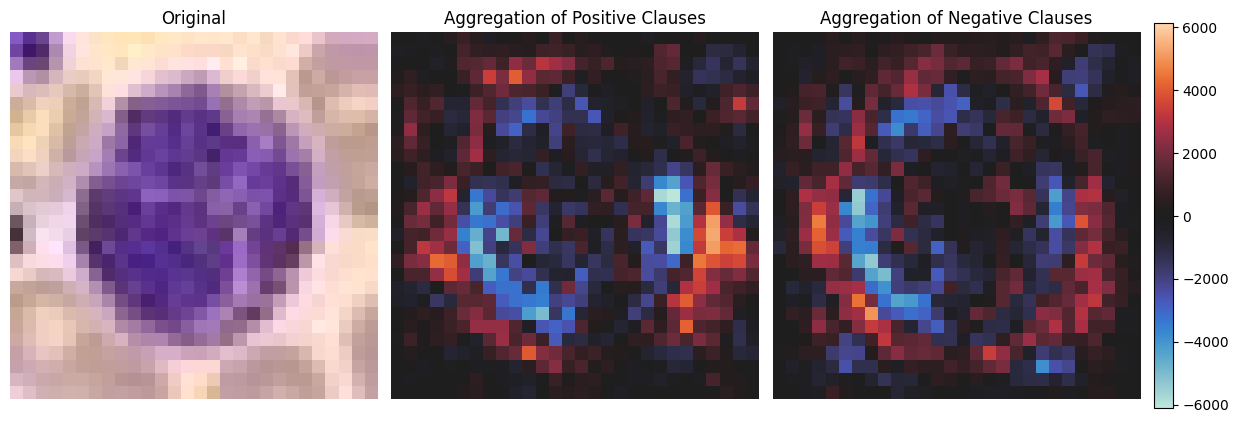

Visualizing sample 1521  |  predicted class: 0
2026-04-15 11:33:37,502 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a5cac0fe0>
2026-04-15 11:33:37,531 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a5c96a840>
2026-04-15 11:33:37,558 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a5ccd7e00>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c0_s1521_chan.svg


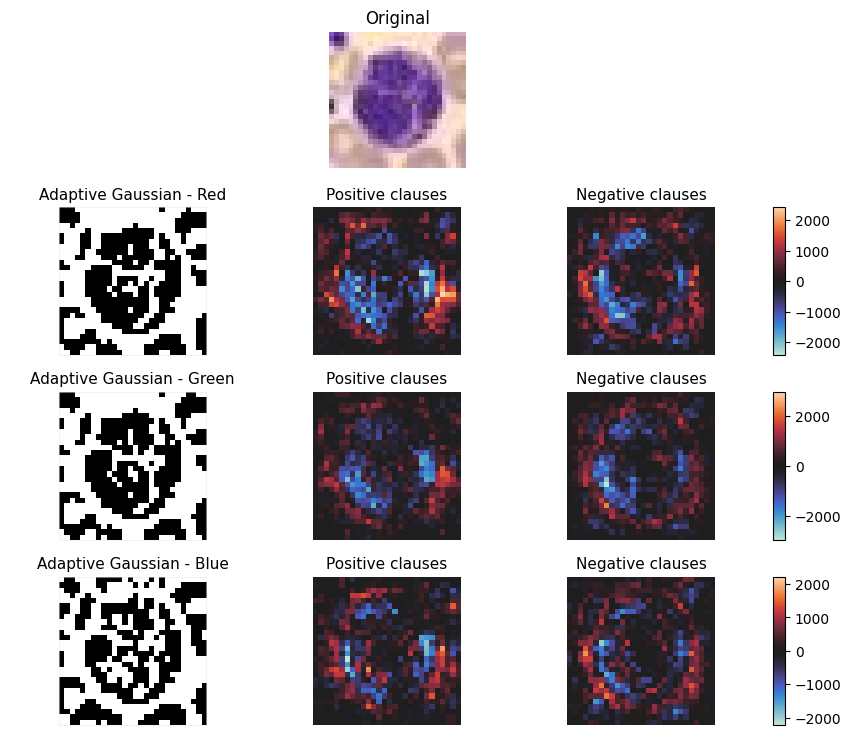

In [10]:
image_index =  1521
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

0
Visualizing sample 2701  |  predicted class: 0
2026-04-15 11:33:49,221 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a5c91cdd0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c0_s2701_aggr.svg


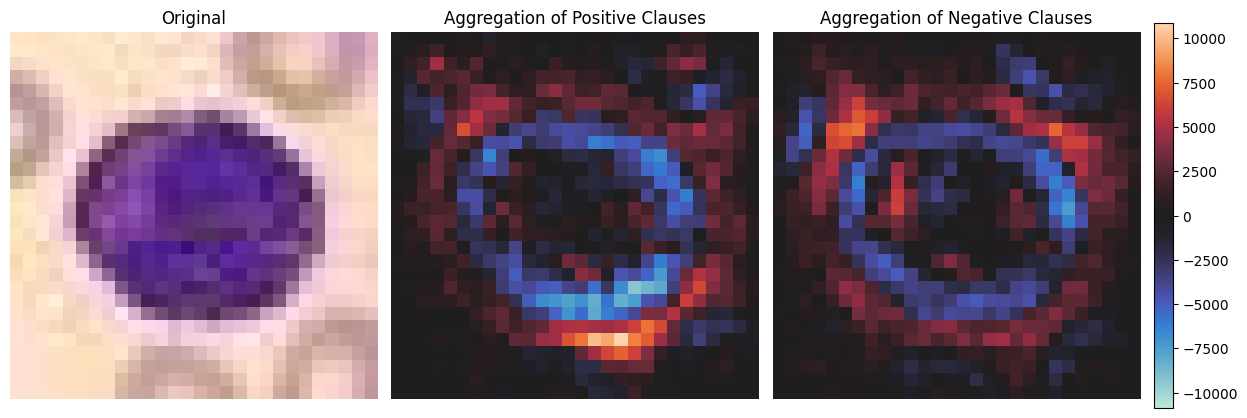

Visualizing sample 2701  |  predicted class: 0
2026-04-15 11:33:53,709 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a596ac440>
2026-04-15 11:33:53,923 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a5c808d70>
2026-04-15 11:33:53,952 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x799a5c7dad80>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c0_s2701_chan.svg


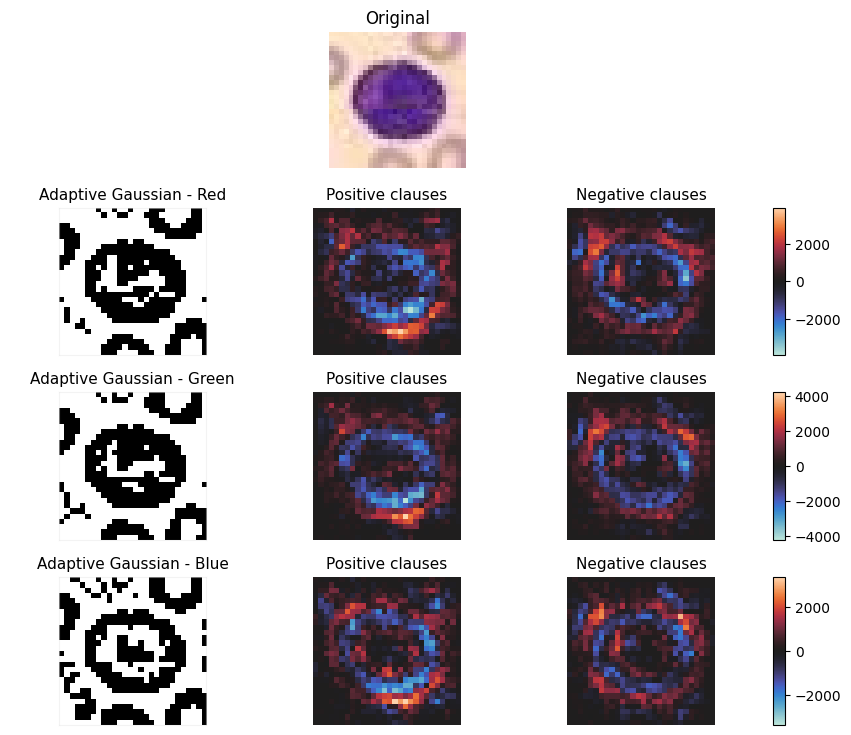

In [11]:
image_index =  2701
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 1 Local Examples 

In [12]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

1
Visualizing sample 1434  |  predicted class: 1
2026-04-10 15:36:21,255 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e056e70>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c1_s1434_aggr.svg


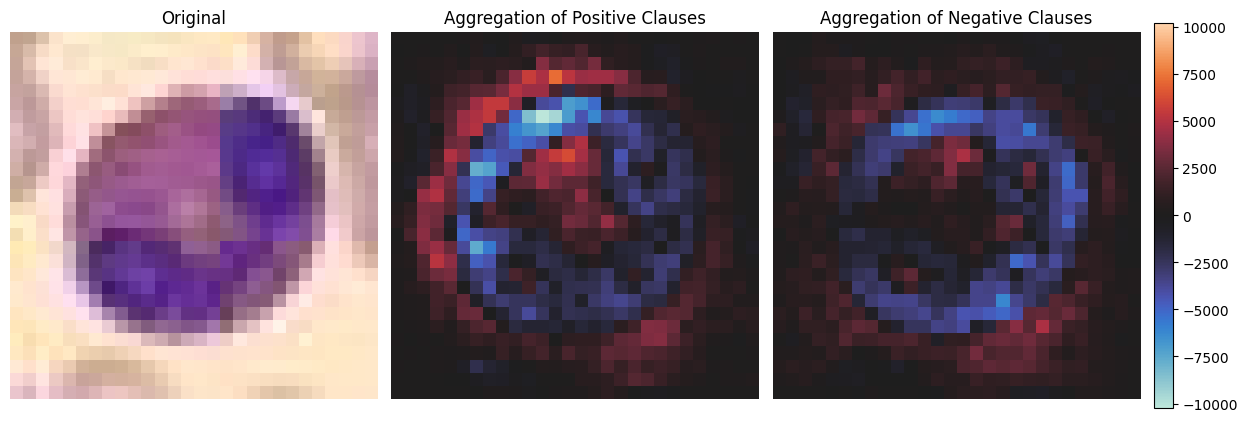

Visualizing sample 1434  |  predicted class: 1
2026-04-10 15:36:25,713 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3a4fc80>
2026-04-10 15:36:25,741 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e11e900>
2026-04-10 15:36:25,770 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3b53740>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c1_s1434_chan.svg


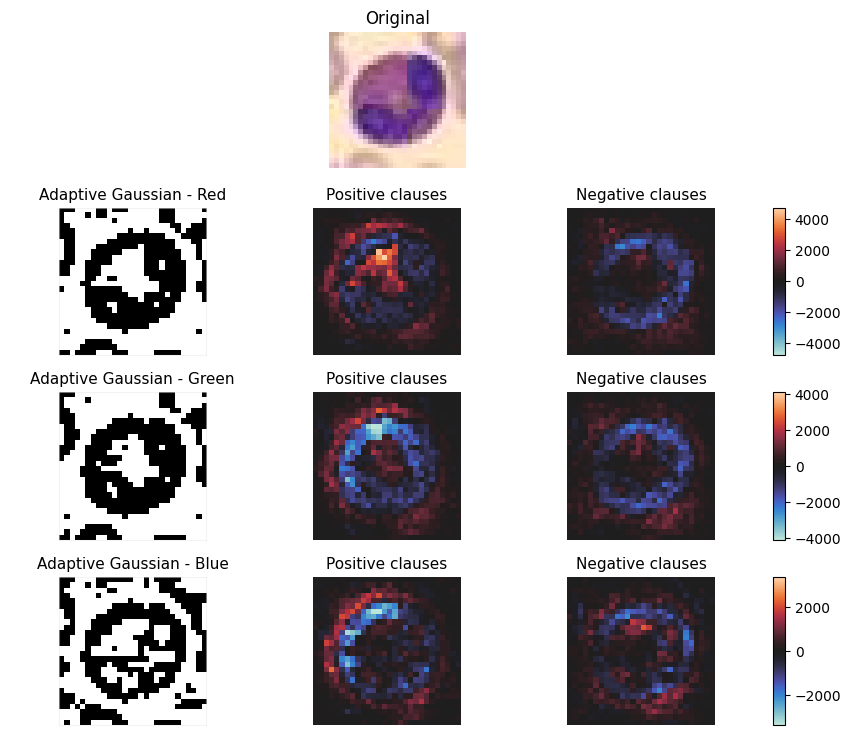

In [13]:
image_index =  1434
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

1
Visualizing sample 2840  |  predicted class: 1
2026-04-10 15:36:30,903 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3e5af90>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c1_s2840_aggr.svg


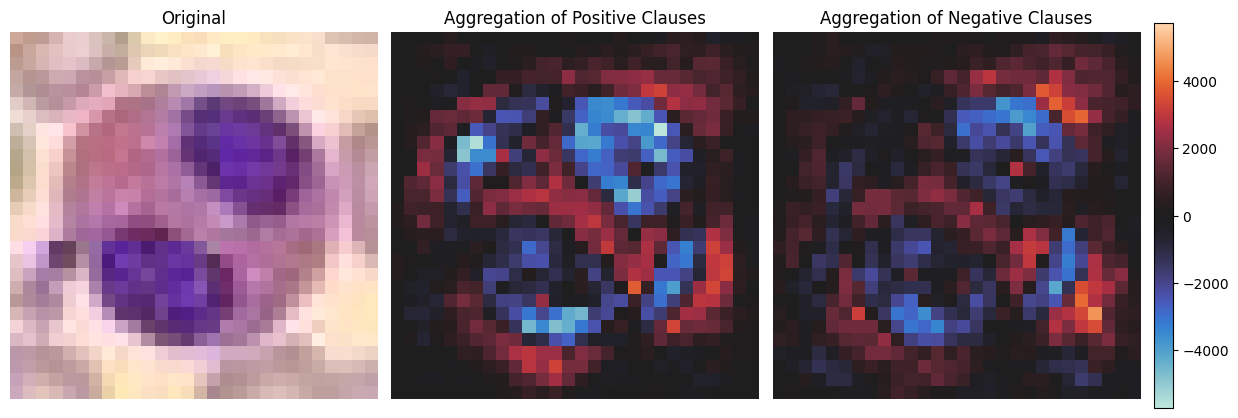

Visualizing sample 2840  |  predicted class: 1
2026-04-10 15:36:36,155 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a75753d0>
2026-04-10 15:36:36,222 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3f72780>
2026-04-10 15:36:36,586 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a7524110>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c1_s2840_chan.svg


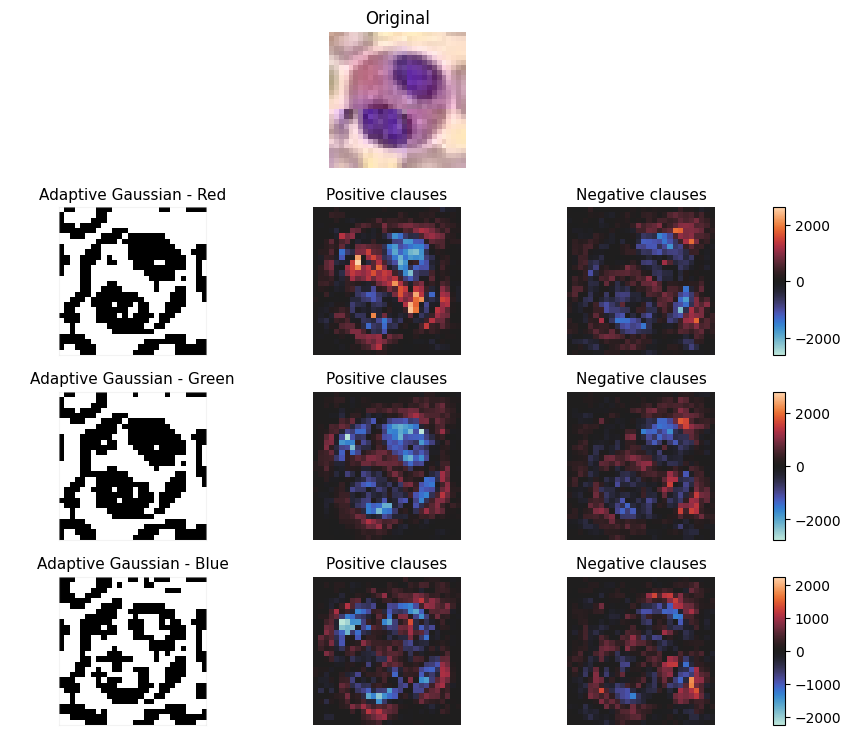

In [14]:
image_index =  2840
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

1
Visualizing sample 2996  |  predicted class: 1
2026-04-10 15:36:43,215 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3c99850>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c1_s2996_aggr.svg


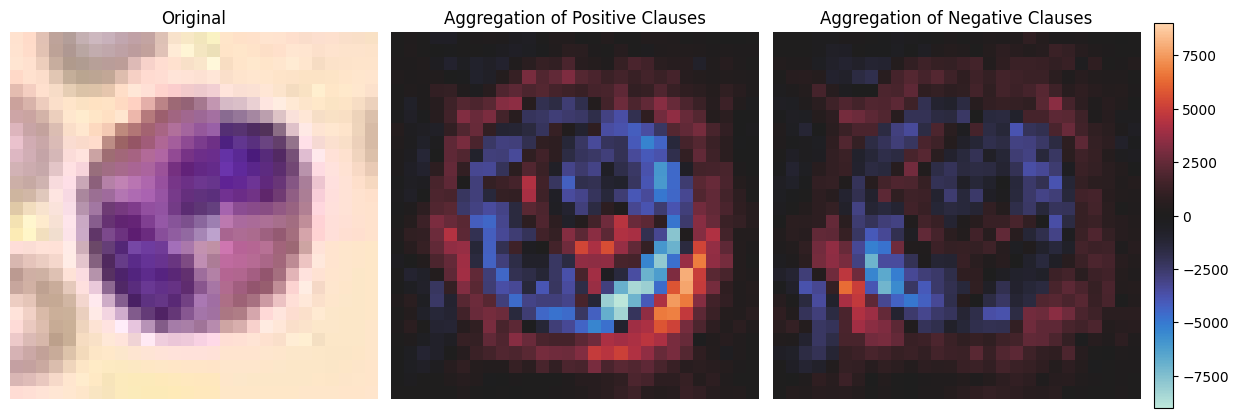

Visualizing sample 2996  |  predicted class: 1
2026-04-10 15:36:48,056 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e11d910>
2026-04-10 15:36:48,084 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3ae8b30>
2026-04-10 15:36:48,112 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3b75c10>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c1_s2996_chan.svg


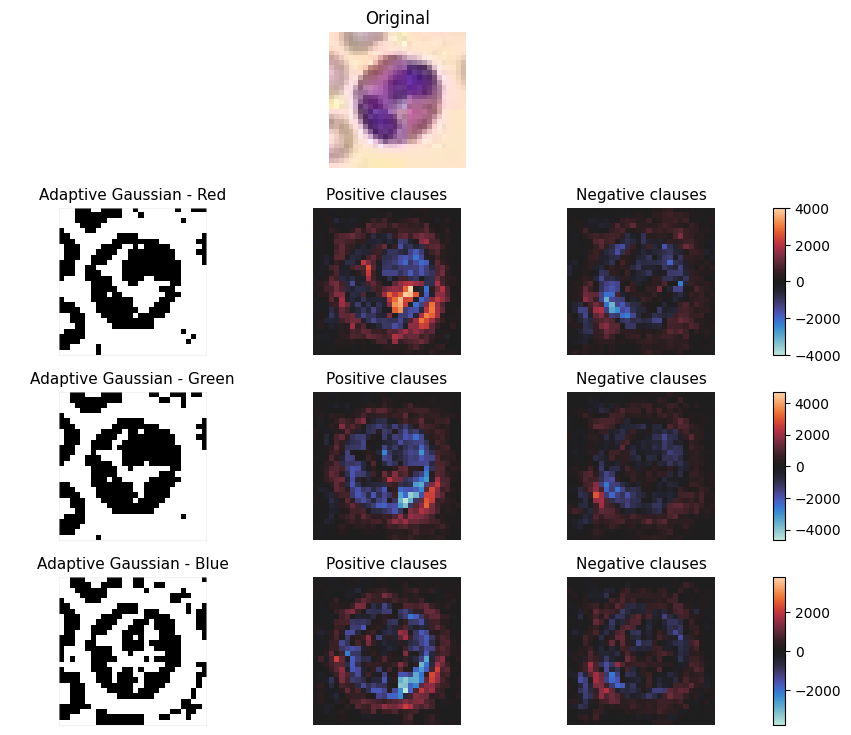

In [15]:
image_index =  2996
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 2 Local Examples 

In [16]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=2, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

2
Visualizing sample 2058  |  predicted class: 2
2026-04-10 15:36:53,597 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3db9940>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c2_s2058_aggr.svg


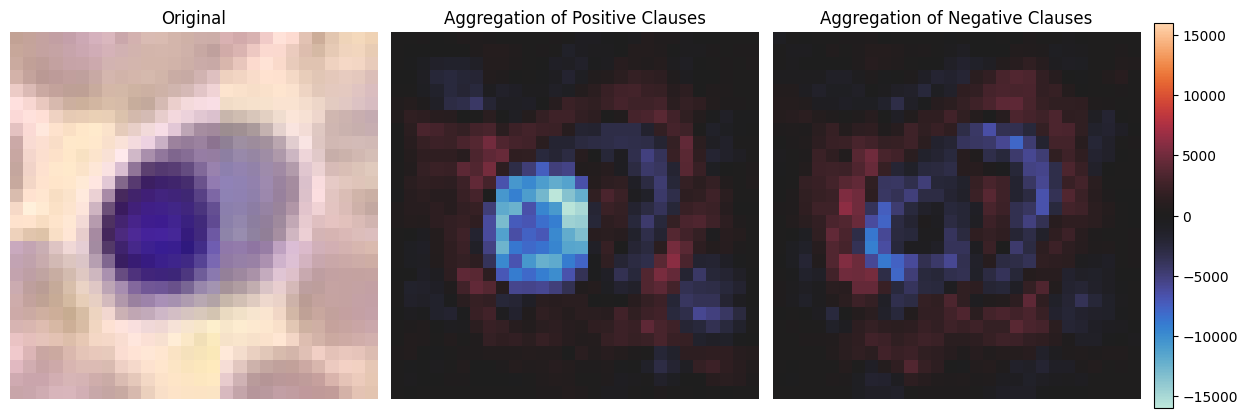

Visualizing sample 2058  |  predicted class: 2
2026-04-10 15:36:58,672 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3b63200>
2026-04-10 15:36:58,700 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3f2f950>
2026-04-10 15:36:58,729 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e18f110>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c2_s2058_chan.svg


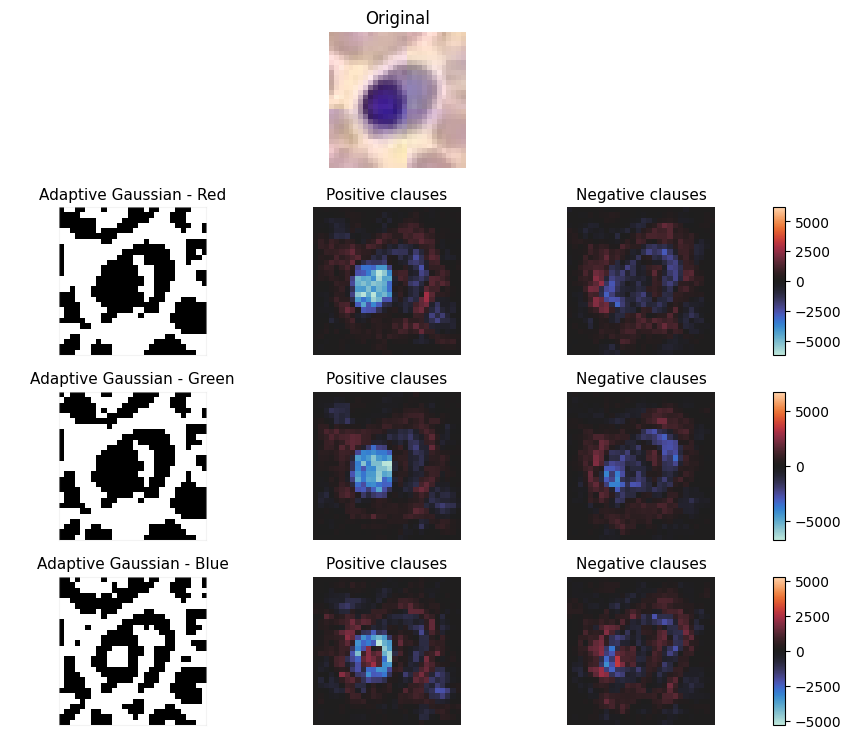

In [17]:
image_index =  2058
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

2
Visualizing sample 331  |  predicted class: 2
2026-04-10 15:37:04,004 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3918925d0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c2_s331_aggr.svg


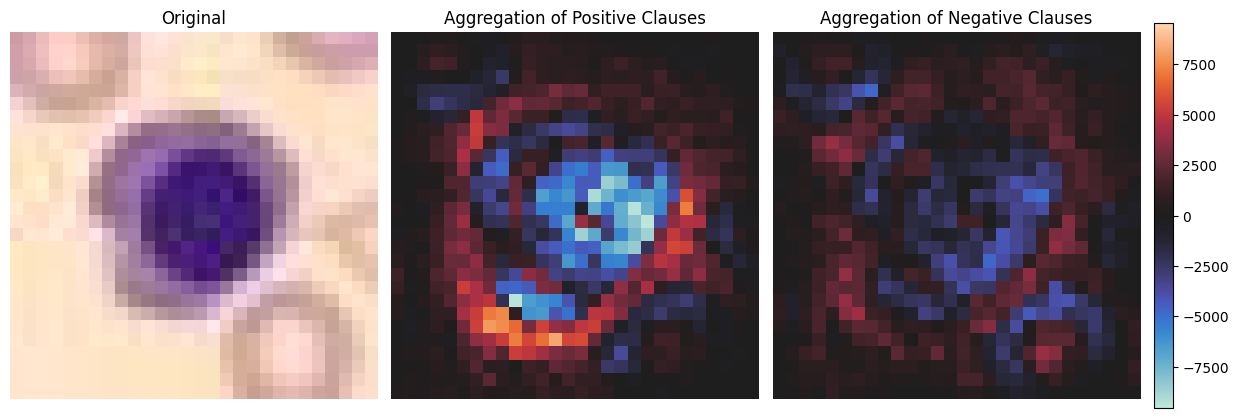

Visualizing sample 331  |  predicted class: 2
2026-04-10 15:37:08,873 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b391973080>
2026-04-10 15:37:08,903 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a75734d0>
2026-04-10 15:37:08,934 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3f9c1d0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c2_s331_chan.svg


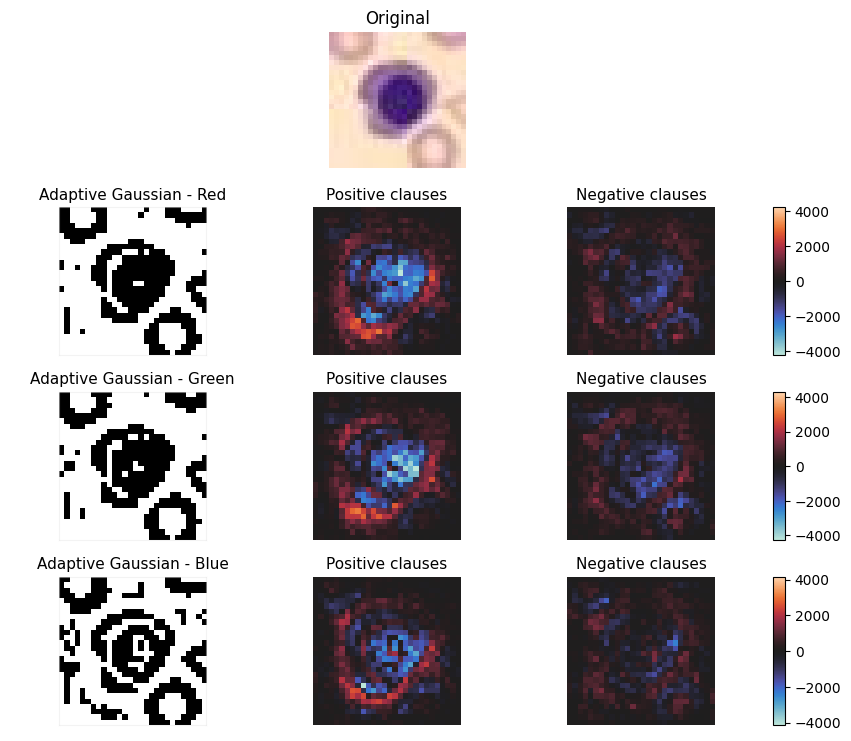

In [18]:
image_index =  331
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

2
Visualizing sample 3220  |  predicted class: 2
2026-04-10 15:37:13,924 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3e11640>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c2_s3220_aggr.svg


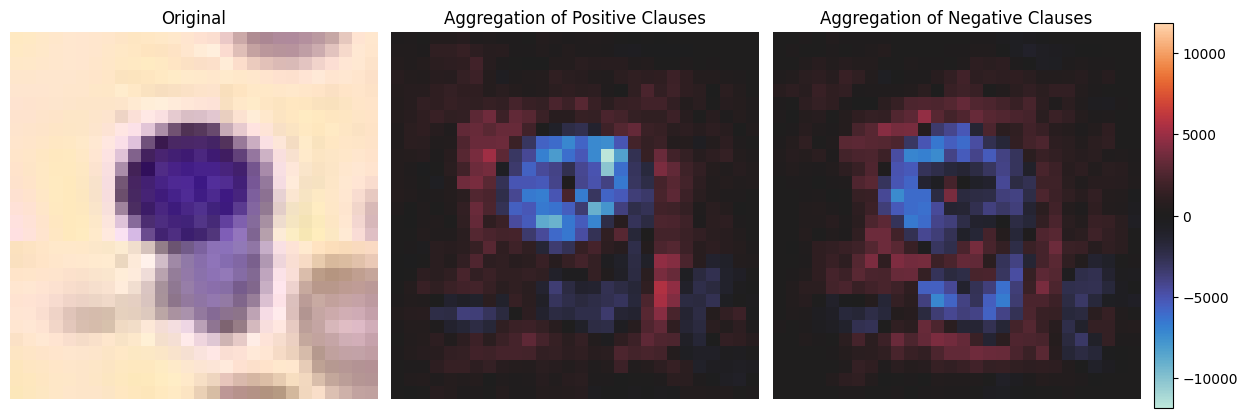

Visualizing sample 3220  |  predicted class: 2
2026-04-10 15:37:18,699 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3a80200>
2026-04-10 15:37:18,745 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3f04ef0>
2026-04-10 15:37:18,773 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e19f530>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c2_s3220_chan.svg


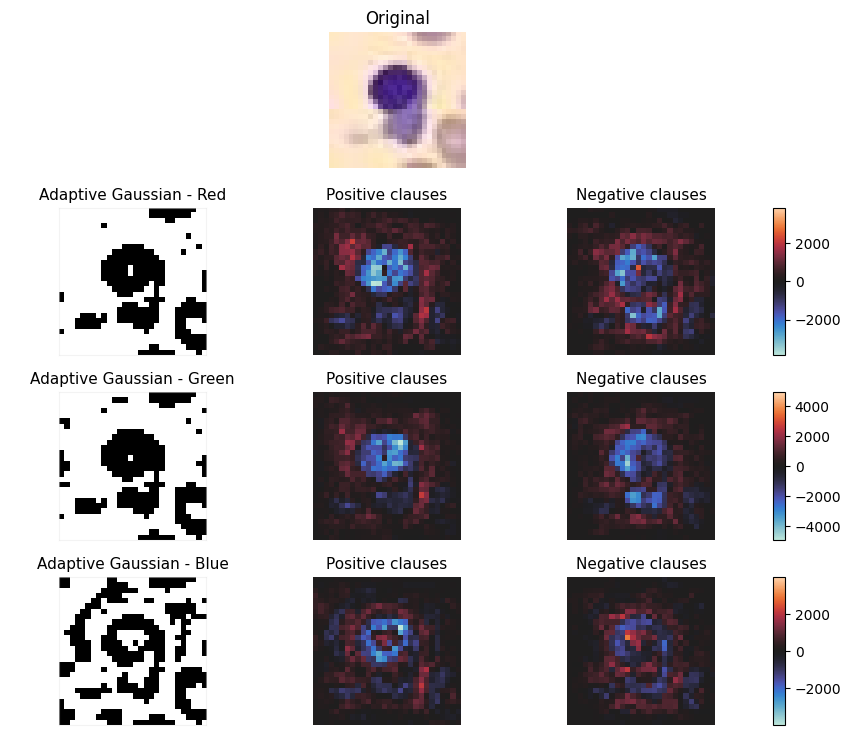

In [19]:
image_index =  3220
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 3 Local Examples 

In [20]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=3, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

3
Visualizing sample 2050  |  predicted class: 3
2026-04-10 15:37:24,572 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3917b41d0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c3_s2050_aggr.svg


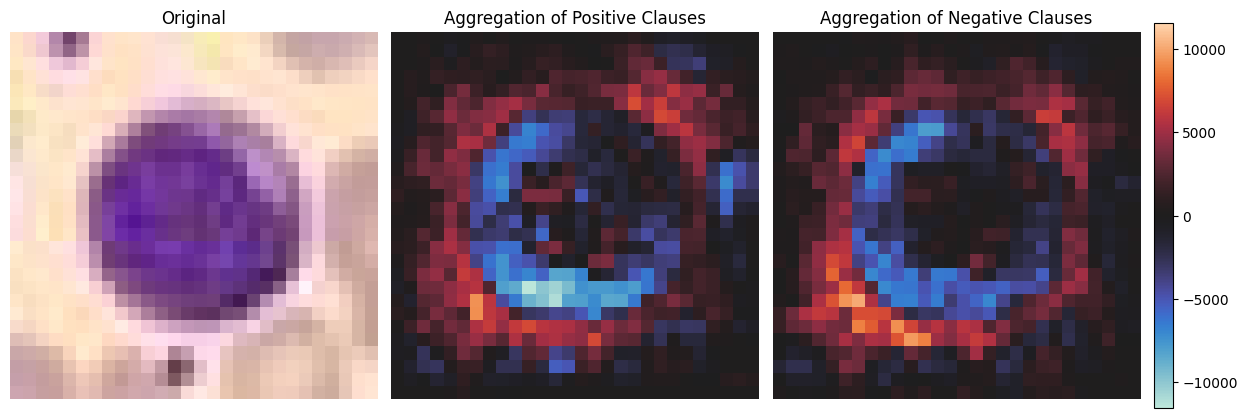

Visualizing sample 2050  |  predicted class: 3
2026-04-10 15:37:29,155 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3b51490>
2026-04-10 15:37:29,184 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a39a43e0>
2026-04-10 15:37:29,212 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3b77b60>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c3_s2050_chan.svg


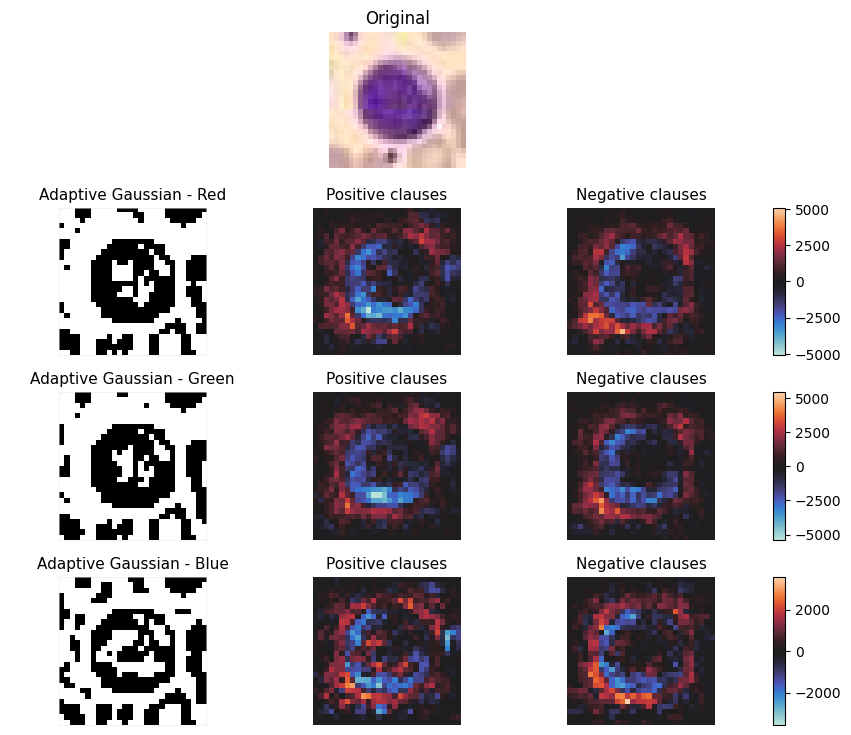

In [21]:
image_index =  2050
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

3
Visualizing sample 2158  |  predicted class: 3
2026-04-10 15:37:33,909 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b391975580>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c3_s2158_aggr.svg


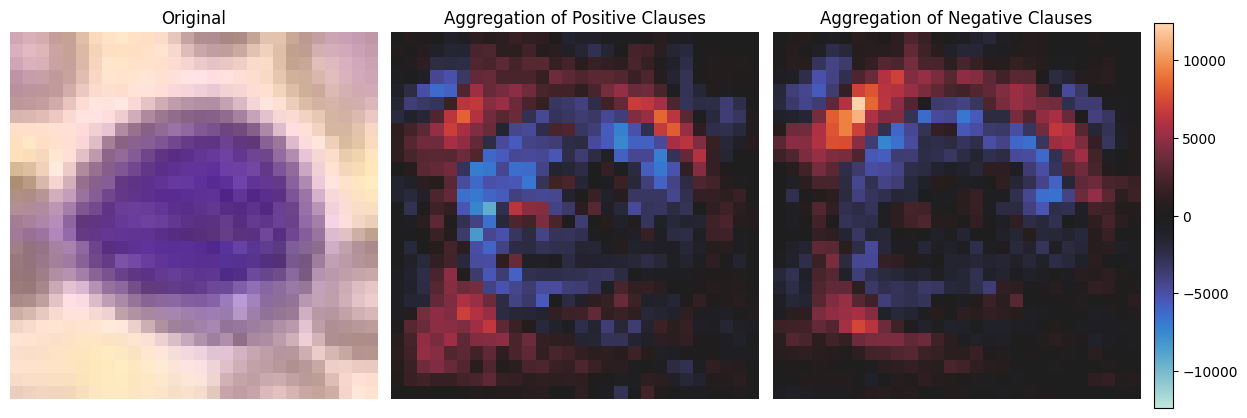

Visualizing sample 2158  |  predicted class: 3
2026-04-10 15:37:38,196 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e0a5c70>
2026-04-10 15:37:38,223 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e15a3c0>
2026-04-10 15:37:38,250 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e026b40>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c3_s2158_chan.svg


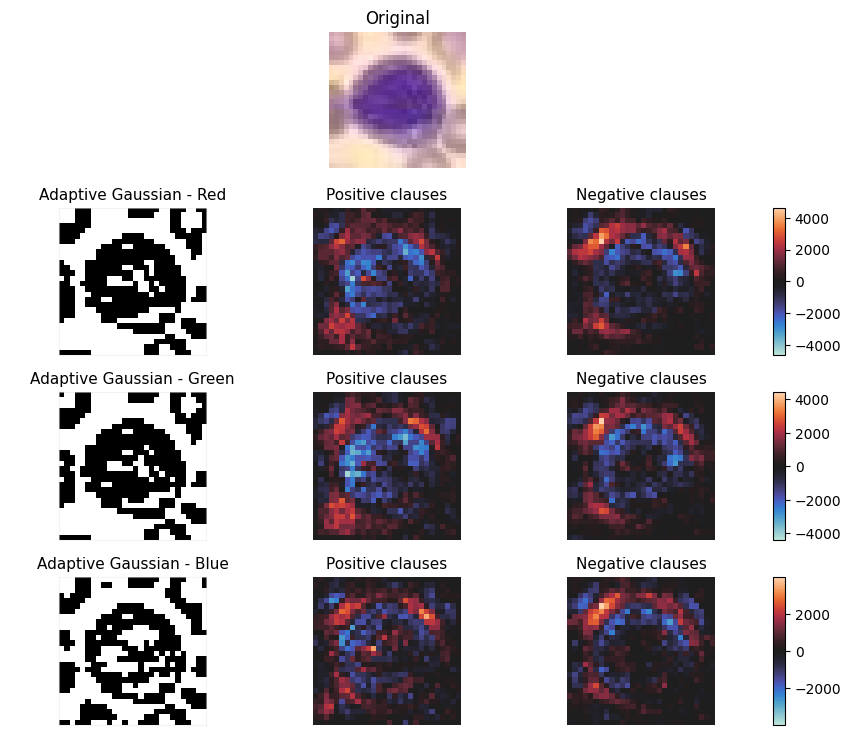

In [22]:
image_index =  2158
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

3
Visualizing sample 2950  |  predicted class: 3
2026-04-10 15:37:43,290 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39193c530>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c3_s2950_aggr.svg


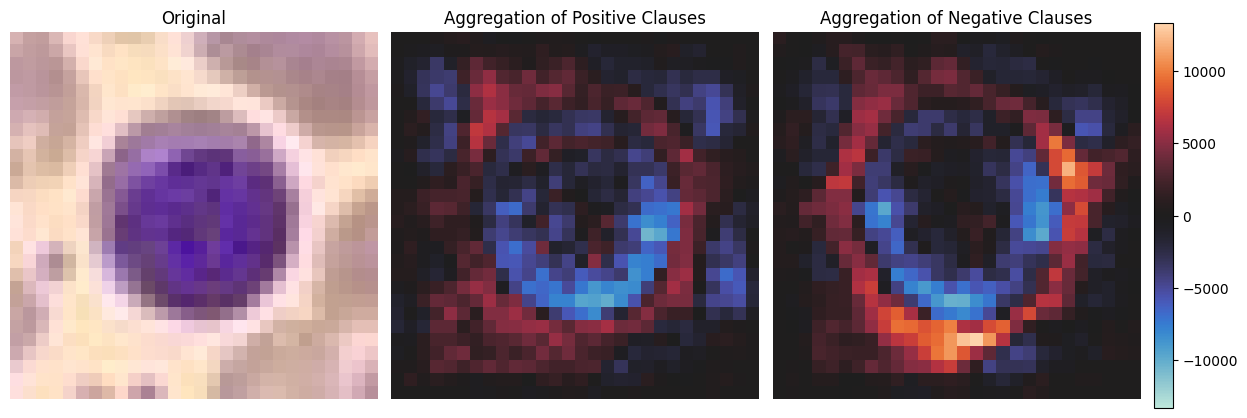

Visualizing sample 2950  |  predicted class: 3
2026-04-10 15:37:47,968 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e1f4080>
2026-04-10 15:37:47,997 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a39a7aa0>
2026-04-10 15:37:48,032 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3aabad0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c3_s2950_chan.svg


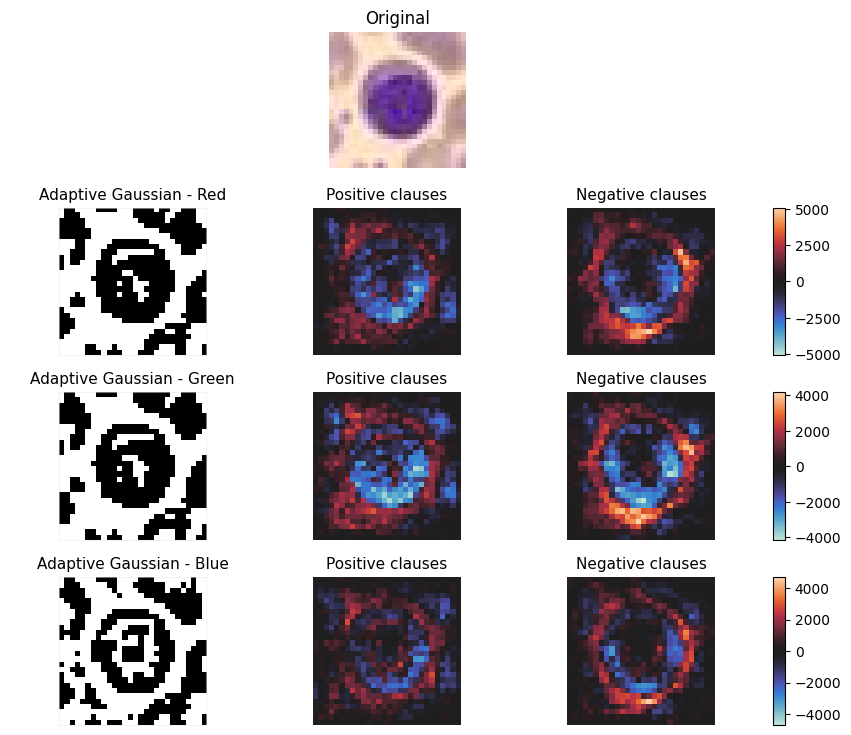

In [23]:
image_index =  2950
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 4 Local Examples 

In [24]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=4, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

4
Visualizing sample 1204  |  predicted class: 4
2026-04-10 15:37:53,853 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3afdc3740>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c4_s1204_aggr.svg


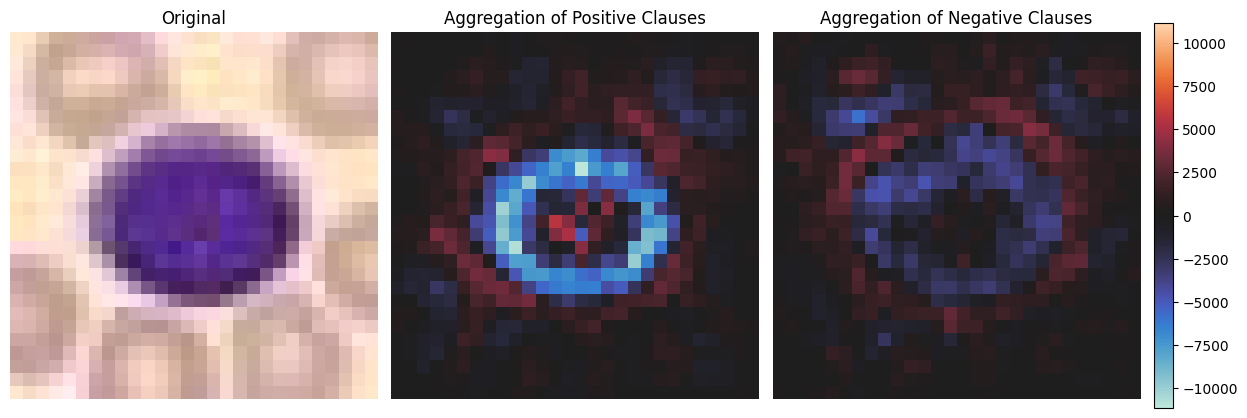

Visualizing sample 1204  |  predicted class: 4
2026-04-10 15:37:59,158 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3c0c290>
2026-04-10 15:37:59,225 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3e5bec0>
2026-04-10 15:37:59,260 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3dddfd0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c4_s1204_chan.svg


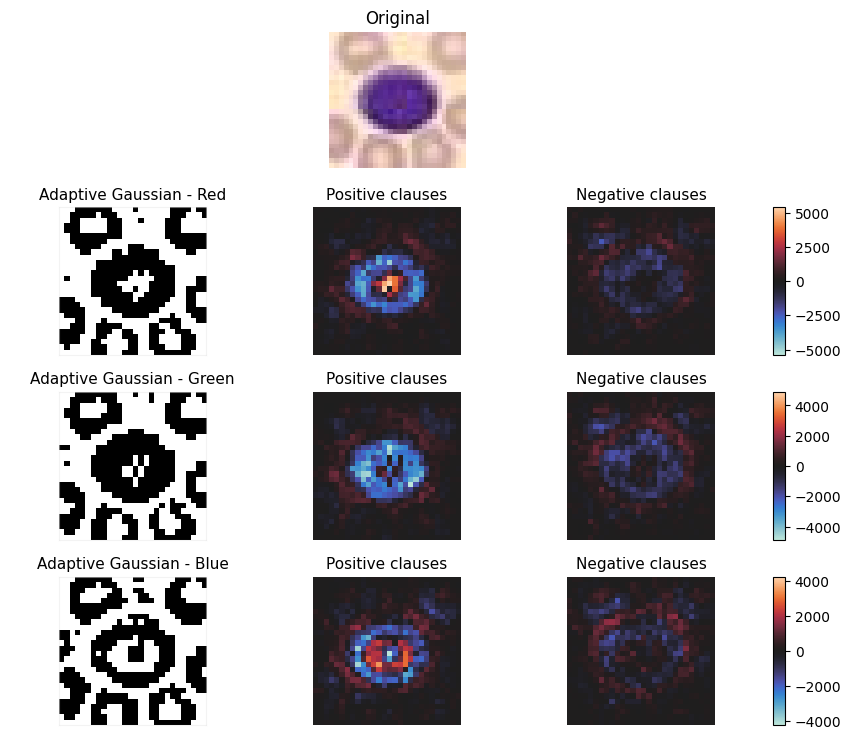

In [25]:
image_index =  1204
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

4
Visualizing sample 60  |  predicted class: 4
2026-04-10 15:38:04,840 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b391a315b0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c4_s60_aggr.svg


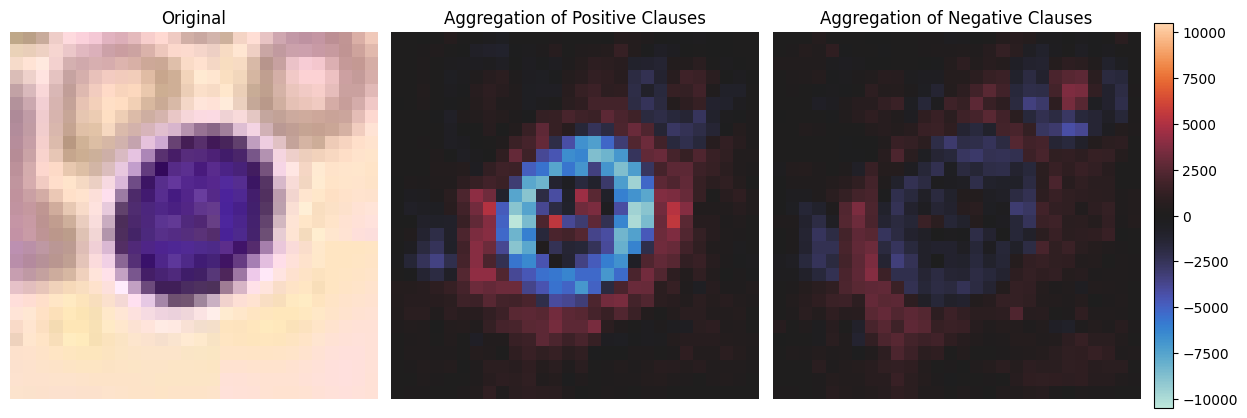

Visualizing sample 60  |  predicted class: 4
2026-04-10 15:38:09,973 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3e2c170>
2026-04-10 15:38:10,001 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3c00ad0>
2026-04-10 15:38:10,053 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3e105c0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c4_s60_chan.svg


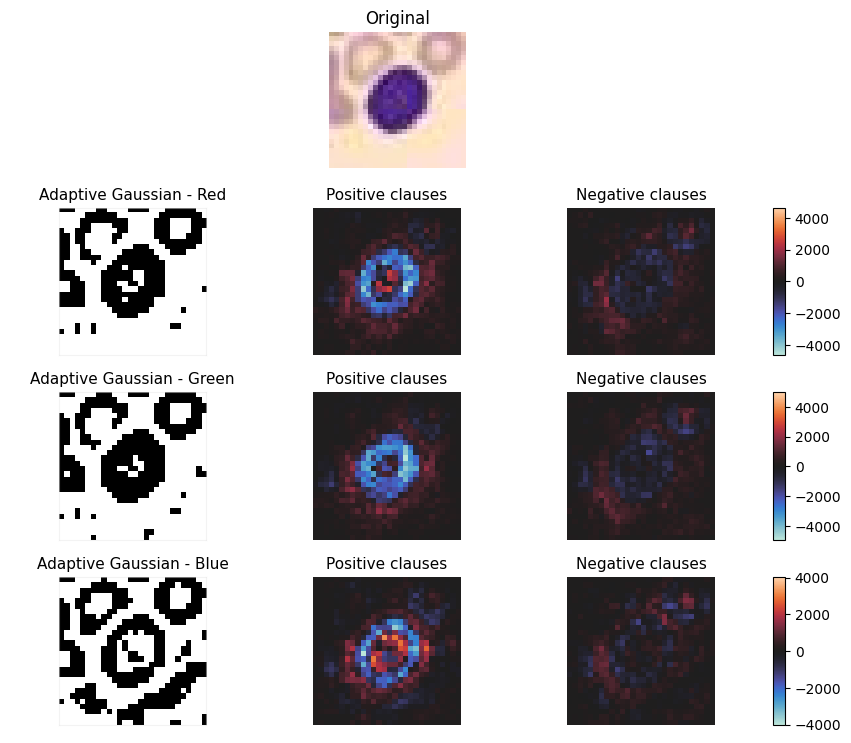

In [26]:
image_index =  60
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

4
Visualizing sample 3167  |  predicted class: 4
2026-04-10 15:38:14,969 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e19fe30>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c4_s3167_aggr.svg


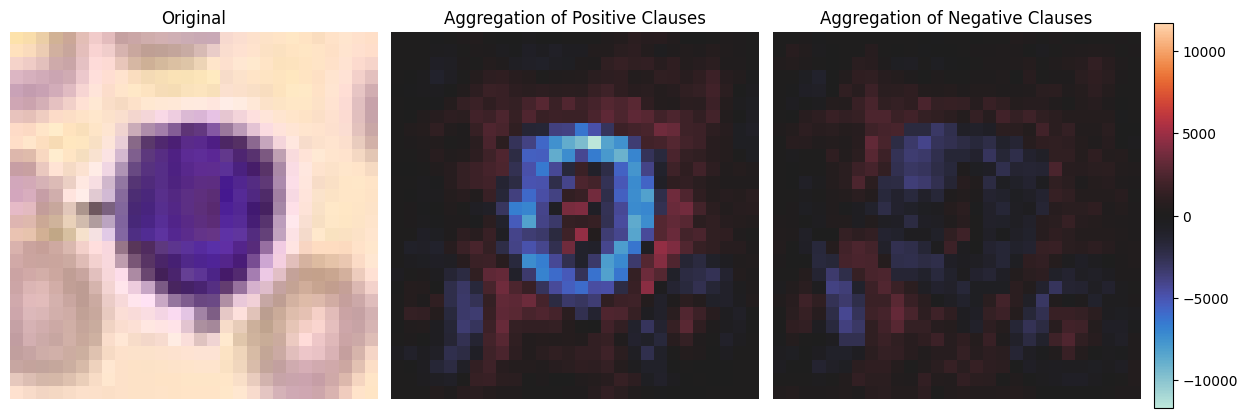

Visualizing sample 3167  |  predicted class: 4
2026-04-10 15:38:19,389 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3bd5fd0>
2026-04-10 15:38:19,419 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e170050>
2026-04-10 15:38:19,449 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b391950bc0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c4_s3167_chan.svg


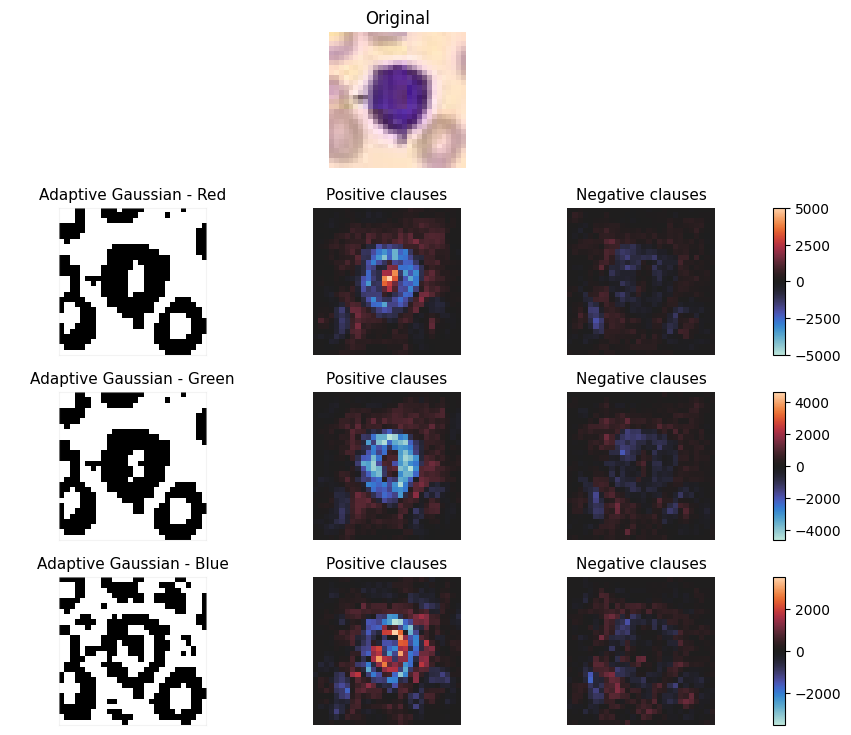

In [27]:
image_index =  3167
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 5 Local Examples 

In [9]:
for i in range(3): 
    print("============================================")
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=5, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 593
True class: 5
Predicted class: 5
Selected image index: 243
True class: 5
Predicted class: 5
Selected image index: 2914
True class: 5
Predicted class: 5


5
2026-04-11 18:57:49,617 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-11 18:57:49,621 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 593  |  predicted class: 5
2026-04-11 18:57:49,655 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c27260200>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c5_s593_aggr.svg


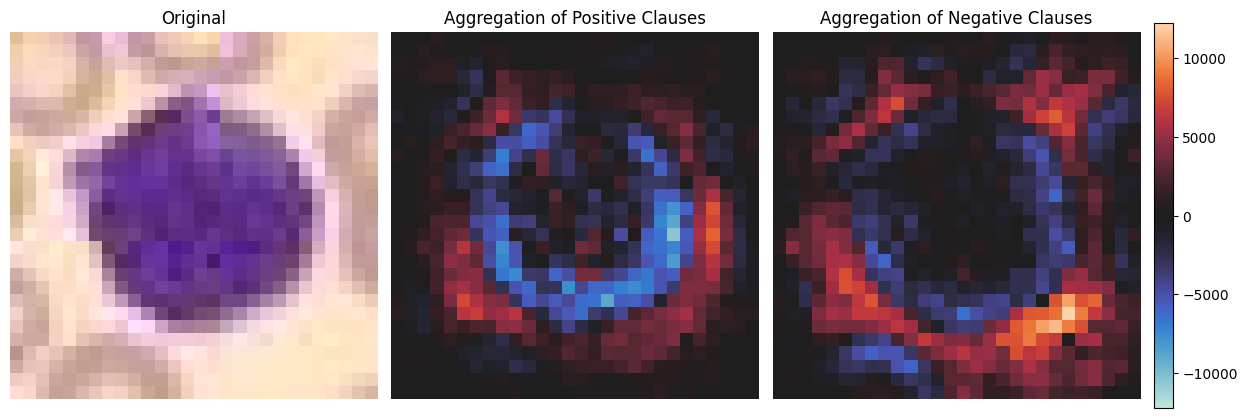

Visualizing sample 593  |  predicted class: 5
2026-04-11 18:57:54,173 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c1b119310>
2026-04-11 18:57:54,331 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c1af8cad0>
2026-04-11 18:57:54,358 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c26dc6de0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c5_s593_chan.svg


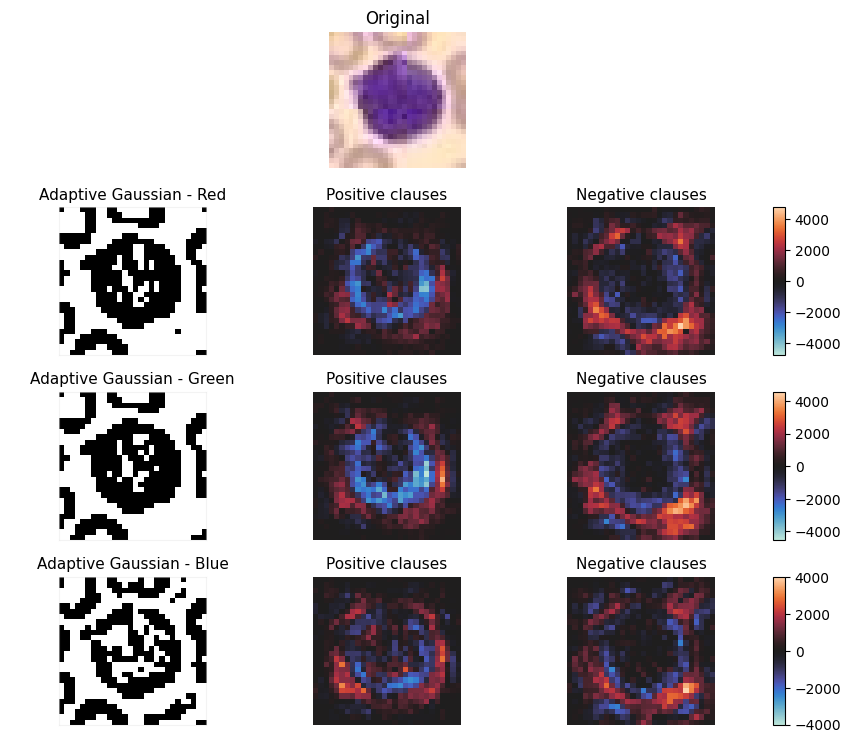

In [10]:
image_index =  593
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

5
Visualizing sample 243  |  predicted class: 5
2026-04-11 18:57:58,929 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c1adbee10>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c5_s243_aggr.svg


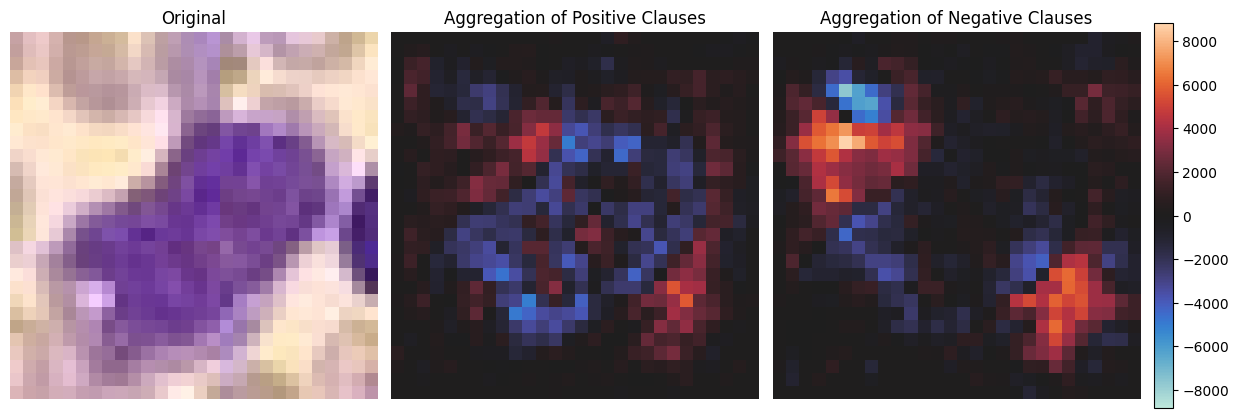

Visualizing sample 243  |  predicted class: 5
2026-04-11 18:58:02,825 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c1ac89a00>
2026-04-11 18:58:02,854 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c1aa51d30>
2026-04-11 18:58:02,883 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c1aaff7a0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c5_s243_chan.svg


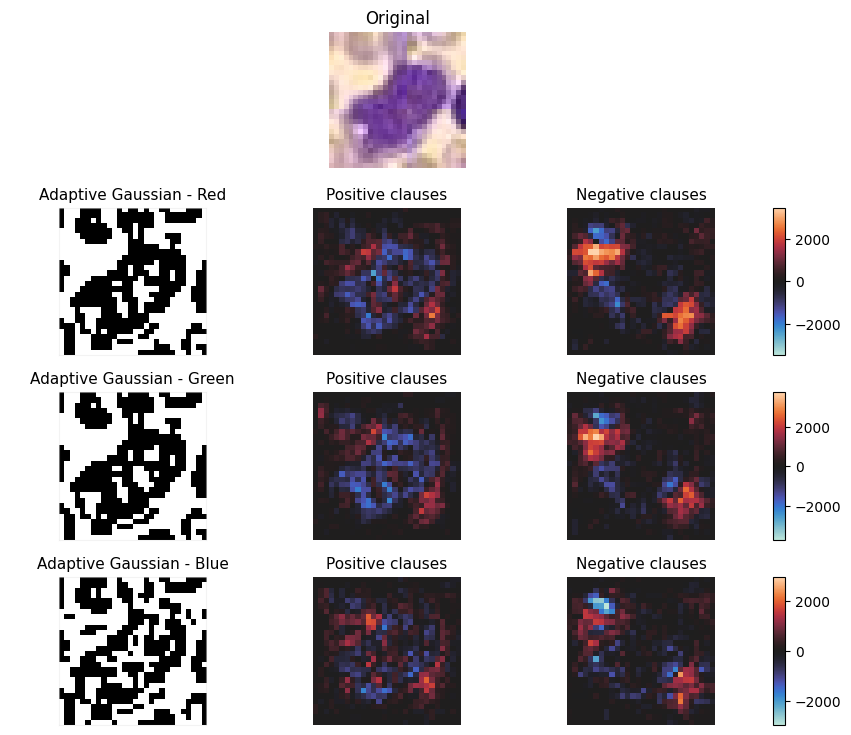

In [11]:
image_index =  243
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

5
Visualizing sample 2914  |  predicted class: 5
2026-04-11 19:10:35,771 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c15007f20>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c5_s2914_aggr.svg


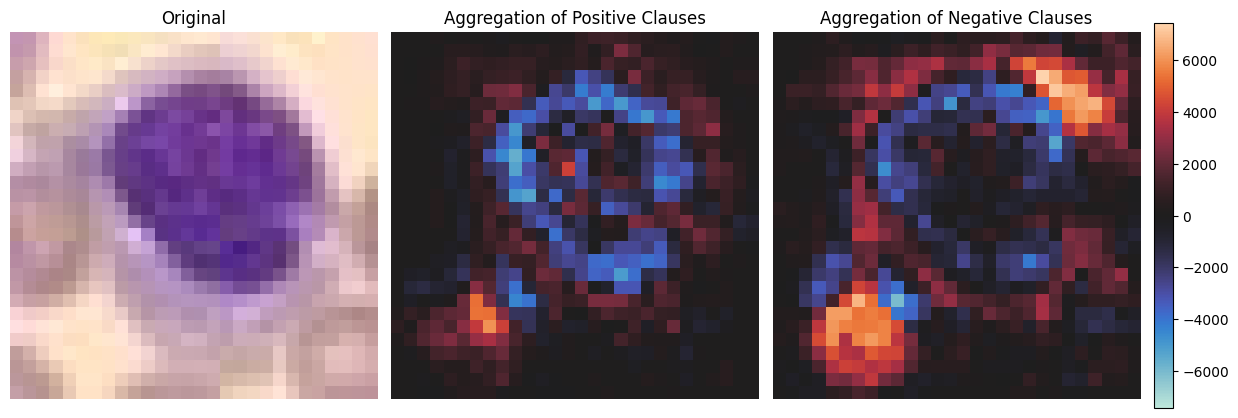

Visualizing sample 2914  |  predicted class: 5
2026-04-11 19:10:39,778 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c08b585c0>
2026-04-11 19:10:39,957 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c150ac0e0>
2026-04-11 19:10:39,986 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x791c0898d100>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c5_s2914_chan.svg


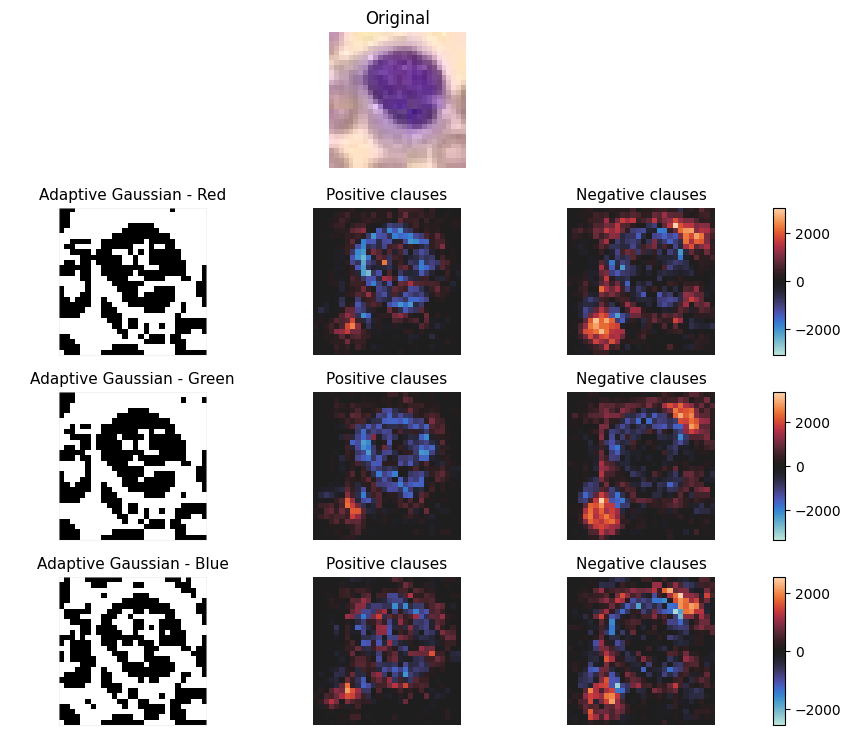

In [12]:
image_index =  2914
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 6 Local Examples 

In [29]:
for i in range(3): 
    print("============================================")
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=6, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 207
True class: 6
Predicted class: 6
Selected image index: 837
True class: 6
Predicted class: 6
Selected image index: 2958
True class: 6
Predicted class: 6


6
Visualizing sample 3378  |  predicted class: 6
2026-04-10 15:52:25,004 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3d12cf0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c6_s3378_aggr.svg


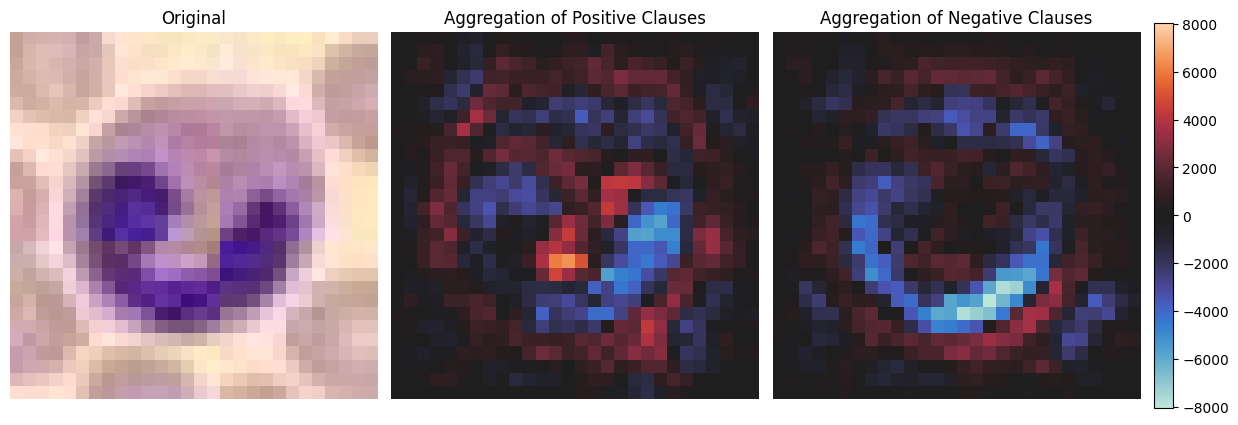

Visualizing sample 3378  |  predicted class: 6
2026-04-10 15:52:30,052 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39193cb00>
2026-04-10 15:52:30,083 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3b39a90>
2026-04-10 15:52:30,110 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3b28230>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c6_s3378_chan.svg


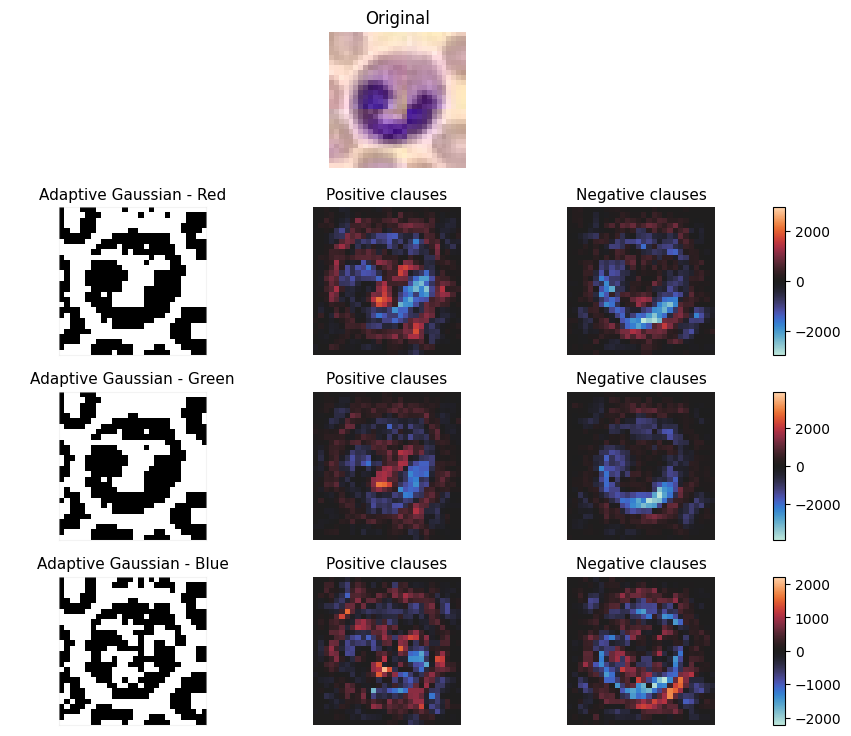

In [30]:
image_index =  3378
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

6
Visualizing sample 3094  |  predicted class: 6
2026-04-10 15:52:34,979 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39df32b70>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c6_s3094_aggr.svg


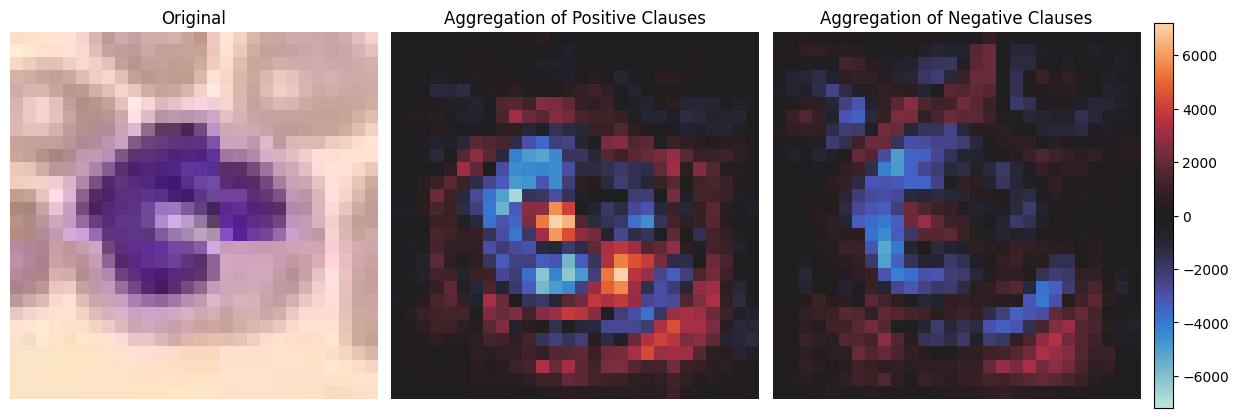

Visualizing sample 3094  |  predicted class: 6
2026-04-10 15:52:39,704 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3c2b2c0>
2026-04-10 15:52:39,742 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3955340>
2026-04-10 15:52:39,770 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3b75a90>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c6_s3094_chan.svg


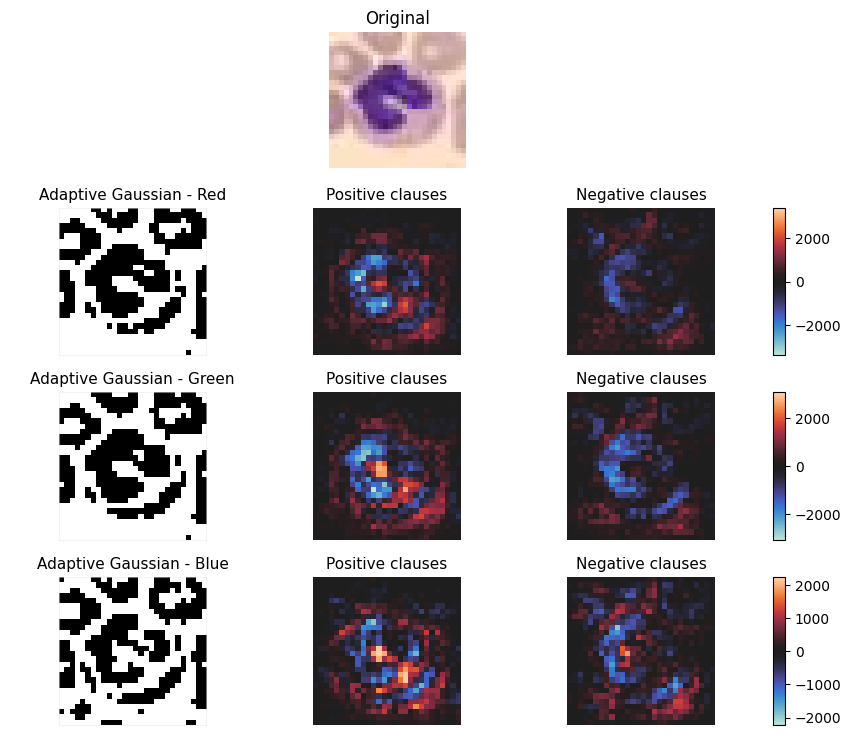

In [31]:
image_index =  3094
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

6


Visualizing sample 192  |  predicted class: 6
2026-04-10 15:52:45,981 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3f046b0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c6_s192_aggr.svg


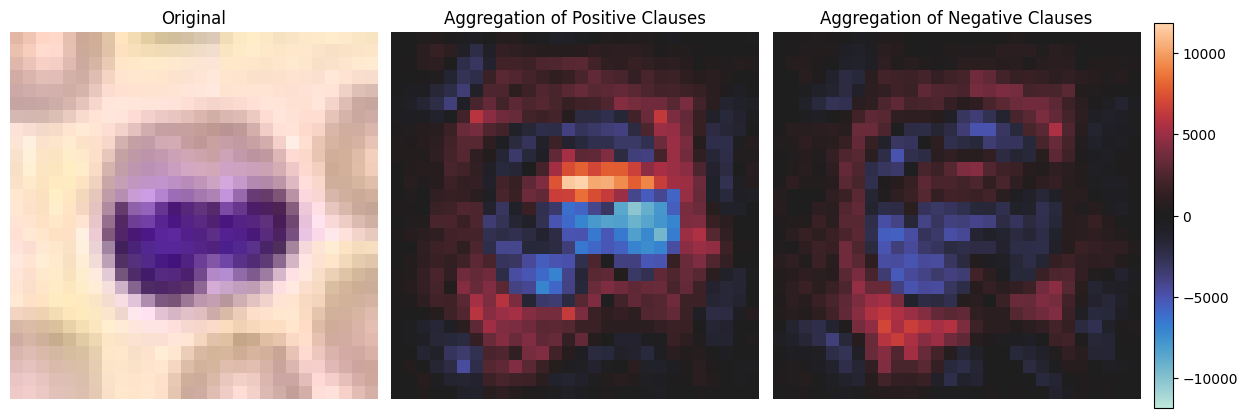

Visualizing sample 192  |  predicted class: 6
2026-04-10 15:52:51,469 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e19d9d0>
2026-04-10 15:52:51,497 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3c00140>
2026-04-10 15:52:51,543 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3c0dfd0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c6_s192_chan.svg


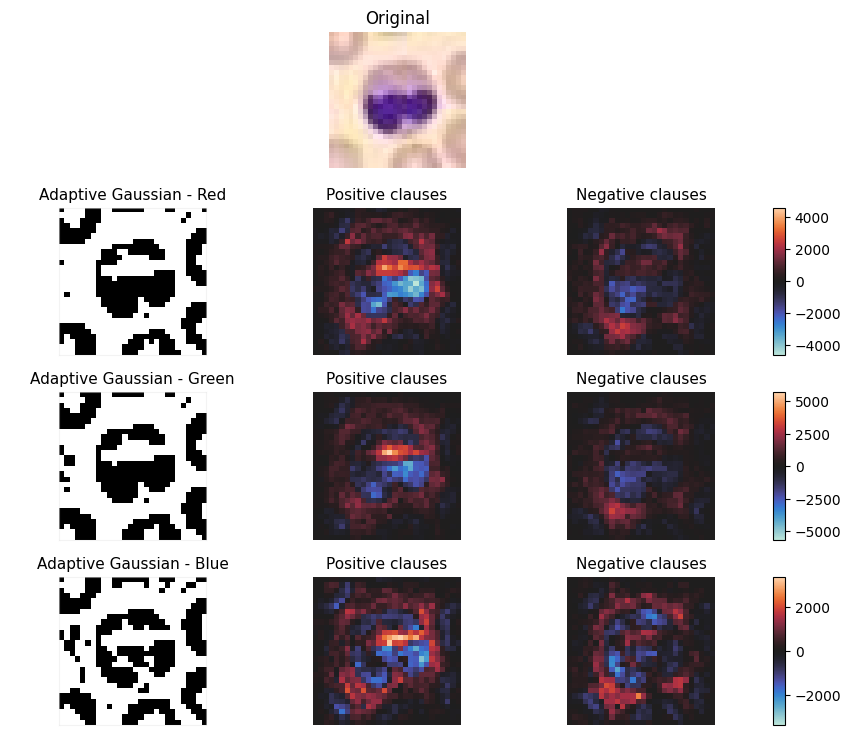

In [32]:
image_index =  192
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 7 Local Examples 

In [33]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=7, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

7
Visualizing sample 2370  |  predicted class: 7
2026-04-10 15:52:57,093 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e1f59d0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c7_s2370_aggr.svg


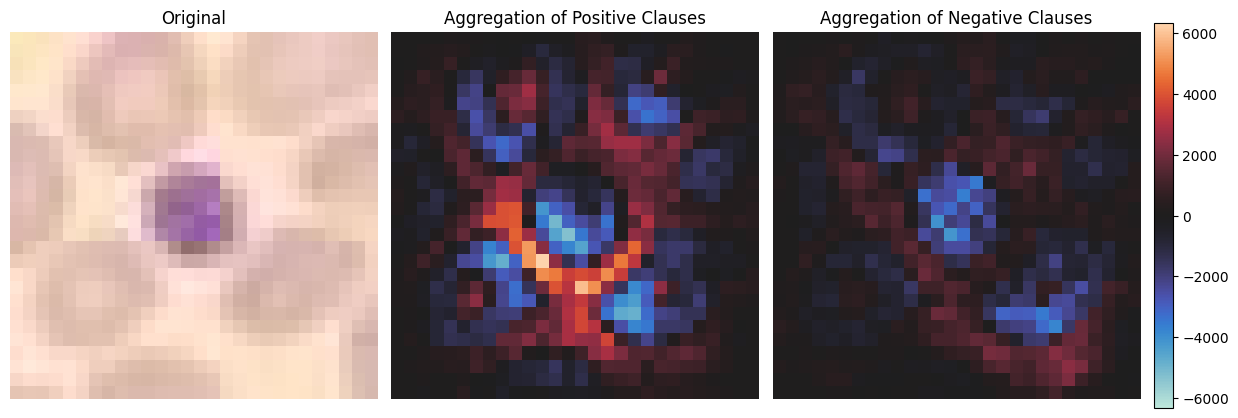

Visualizing sample 2370  |  predicted class: 7
2026-04-10 15:53:02,624 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a400ba10>
2026-04-10 15:53:02,658 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3b53740>
2026-04-10 15:53:02,726 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a4009310>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c7_s2370_chan.svg


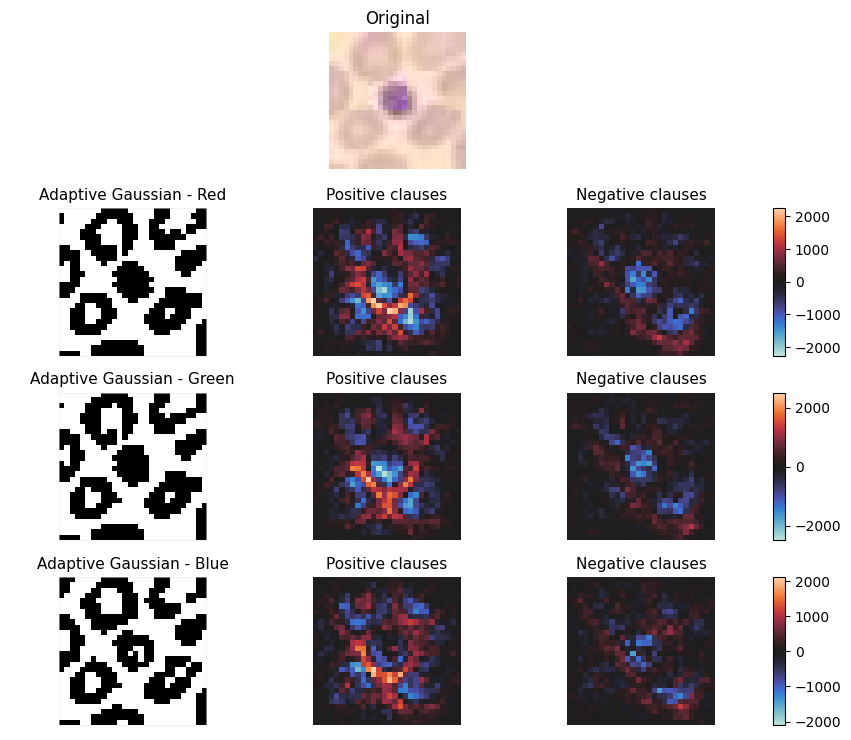

In [34]:
image_index =  2370
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

7
Visualizing sample 2700  |  predicted class: 7
2026-04-10 15:53:07,657 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3917a09e0>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c7_s2700_aggr.svg


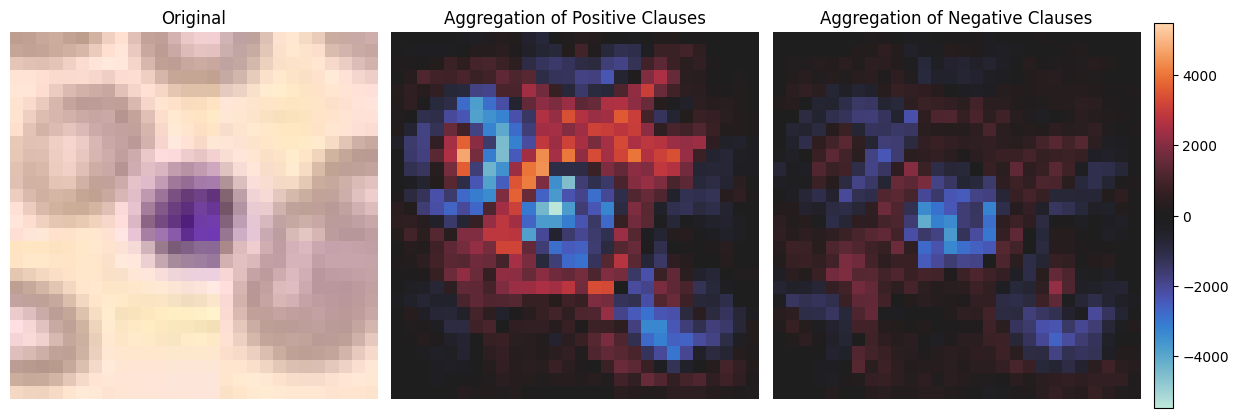

Visualizing sample 2700  |  predicted class: 7
2026-04-10 15:53:12,205 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e173f80>
2026-04-10 15:53:12,382 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a752f350>
2026-04-10 15:53:12,410 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3b03110>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c7_s2700_chan.svg


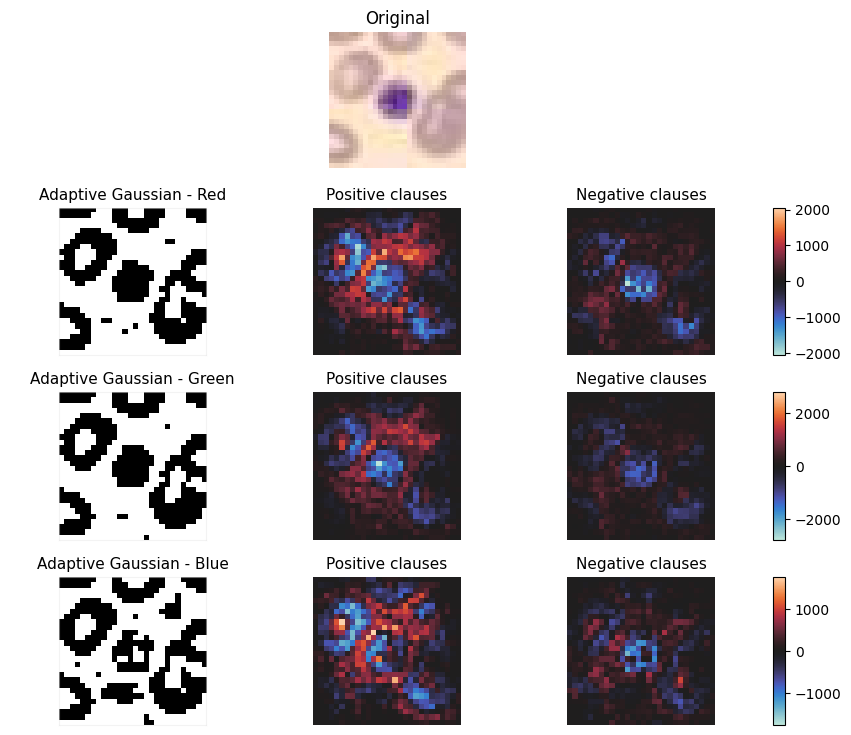

In [35]:
image_index =  2700
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

7
Visualizing sample 2663  |  predicted class: 7
2026-04-10 15:53:16,958 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e1d2540>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c7_s2663_aggr.svg


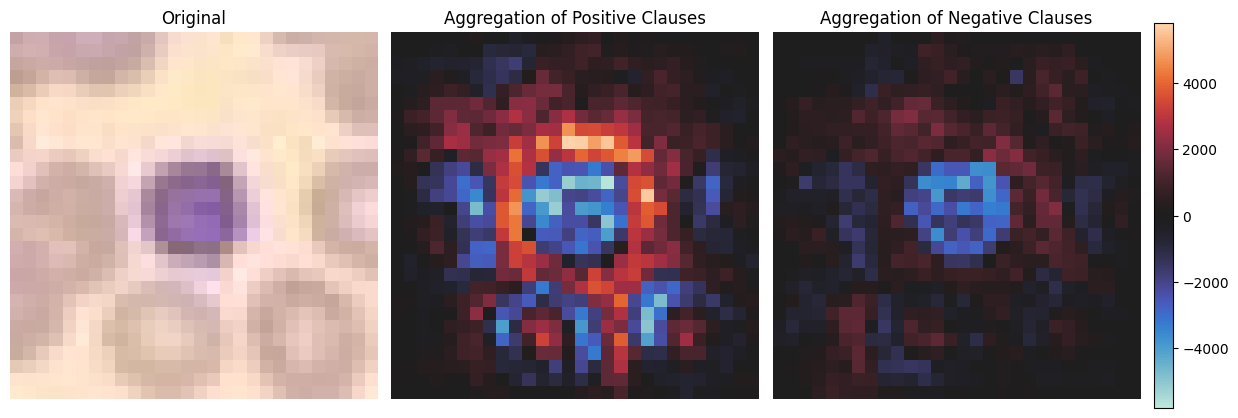

Visualizing sample 2663  |  predicted class: 7
2026-04-10 15:53:21,728 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3919ff590>
2026-04-10 15:53:21,754 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b3a3980530>
2026-04-10 15:53:21,782 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79b39e1d3110>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_lh_c7_s2663_chan.svg


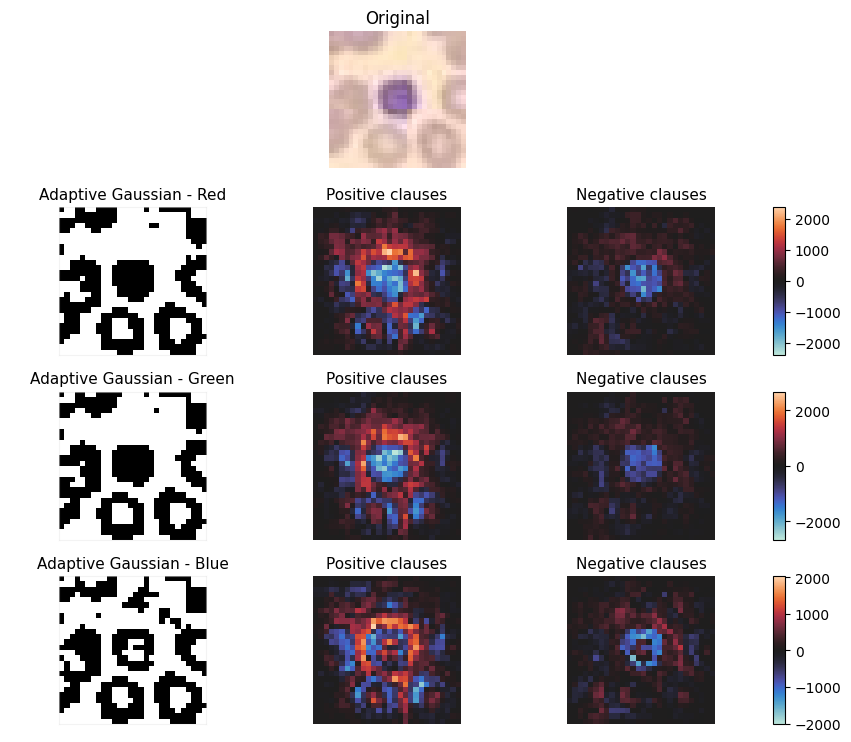

In [36]:
image_index =  2663
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Global Heatmap 0

In [6]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 0

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:33:51,567 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:33:51,569 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:33:51,595 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7c57b27948f0>


Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c0.svg


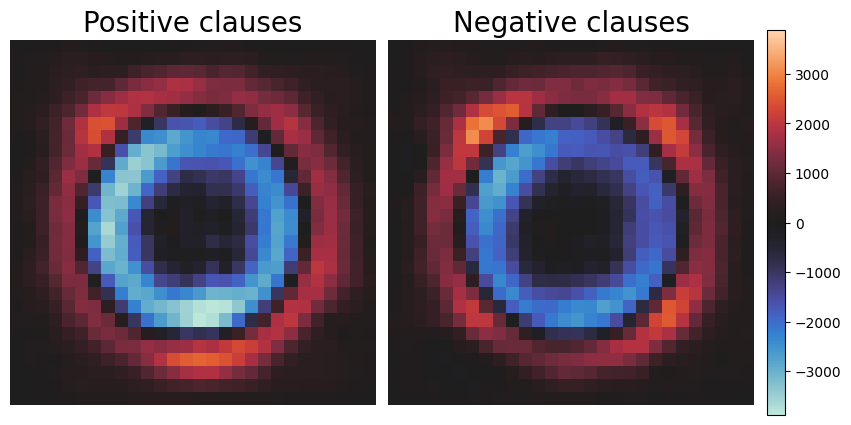

pos shape: (28, 28), min: -3882.97, max: 2665.24
neg shape: (28, 28), min: -3014.99, max: 3071.43
saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c0.svg


In [7]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 1

In [8]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 1

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:33:51,975 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7c5798b1a840>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c1.svg


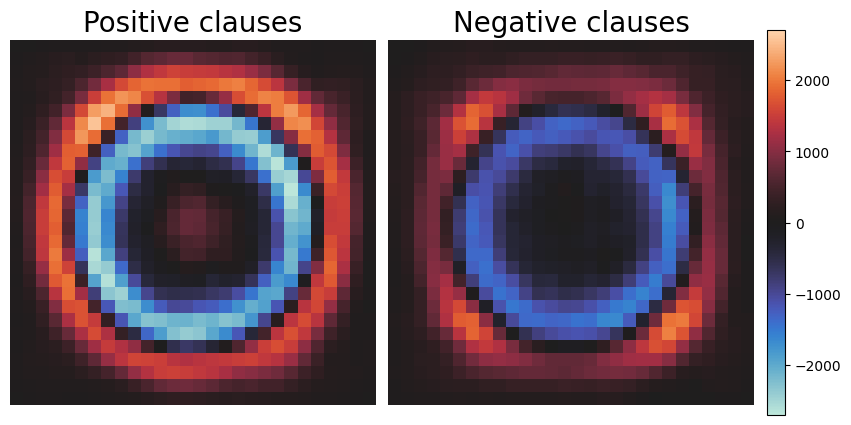

pos shape: (28, 28), min: -2706.22, max: 2563.43
neg shape: (28, 28), min: -1733.62, max: 2069.32
saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c1.svg


In [9]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 2

In [10]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 2

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:33:52,338 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7c57924c2180>


Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c2.svg


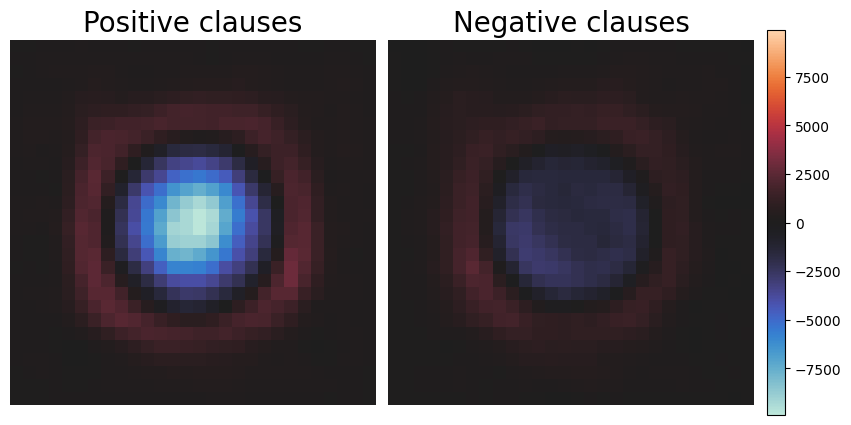

pos shape: (28, 28), min: -9906.06, max: 3004.58
neg shape: (28, 28), min: -2918.41, max: 2447.26
saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c2.svg


In [11]:
target_class = 2
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 3

In [12]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 3

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:33:53,344 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7c57924b5640>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c3.svg


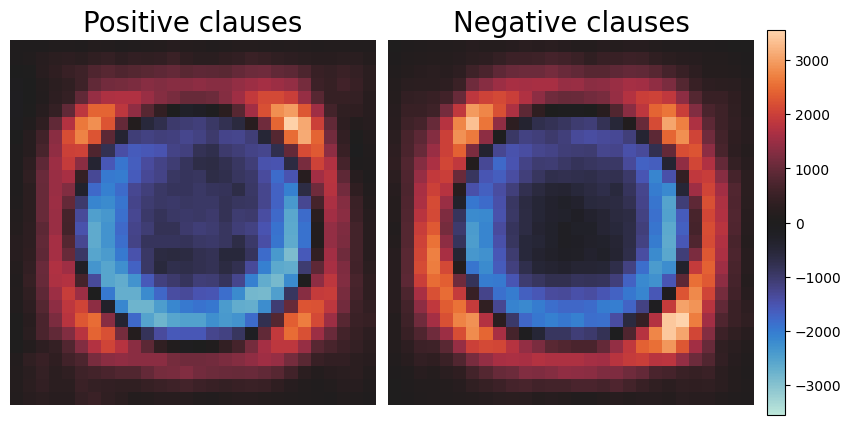

pos shape: (28, 28), min: -2935.35, max: 3509.29
neg shape: (28, 28), min: -2652.91, max: 3550.99
saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c3.svg


In [13]:
target_class = 3
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 4

In [14]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 4

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:33:53,737 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7c5798ad45c0>


Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c4.svg


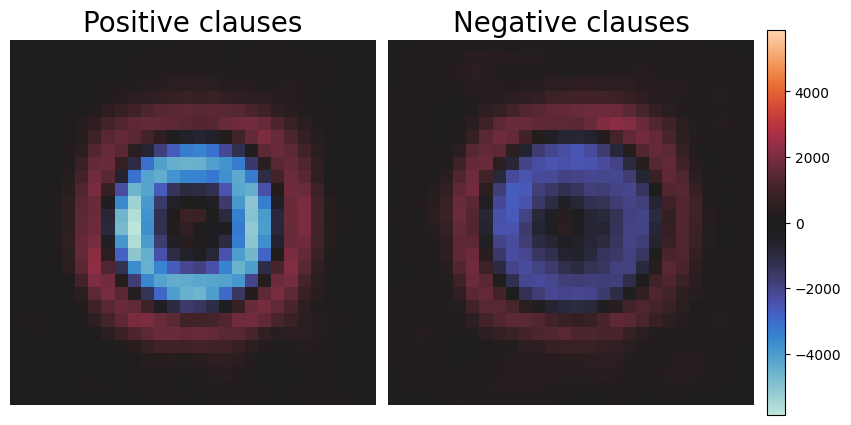

pos shape: (28, 28), min: -5867.91, max: 2246.61
neg shape: (28, 28), min: -2724.81, max: 2234.07
saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c4.svg


In [15]:
target_class = 4
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 5

In [16]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 5

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:33:54,207 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7c5792534e90>


Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c5.svg


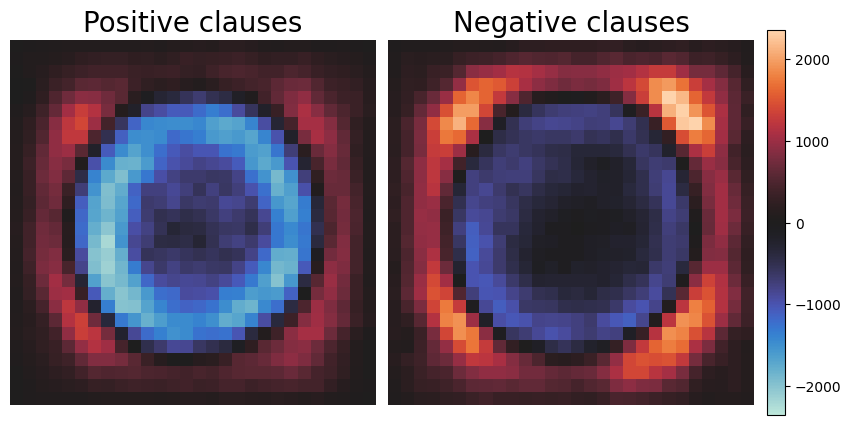

pos shape: (28, 28), min: -2226.17, max: 1385.49
neg shape: (28, 28), min: -1129.12, max: 2358.11
saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c5.svg


In [17]:
target_class = 5
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 6

In [18]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 6

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:33:54,673 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7c57923a2600>
Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c6.svg


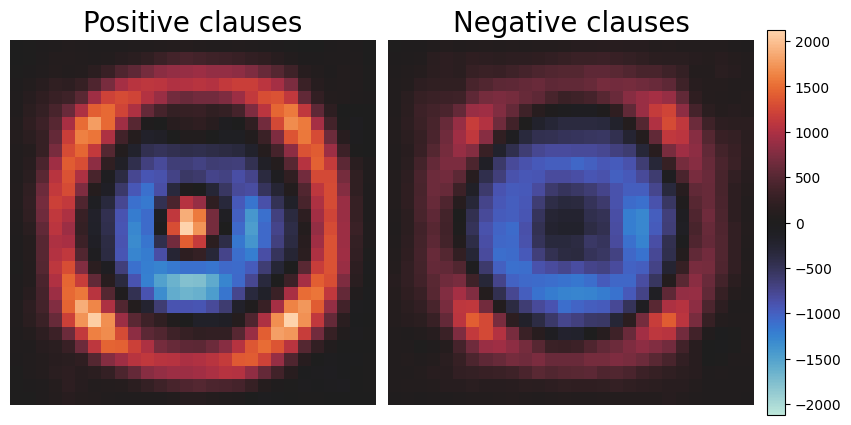

pos shape: (28, 28), min: -1777.02, max: 2122.48
neg shape: (28, 28), min: -1291.51, max: 1425.44
saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c6.svg


In [19]:
target_class = 6
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 7

In [20]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 7

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:33:55,101 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7c57921bf980>


Saved to saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c7.svg


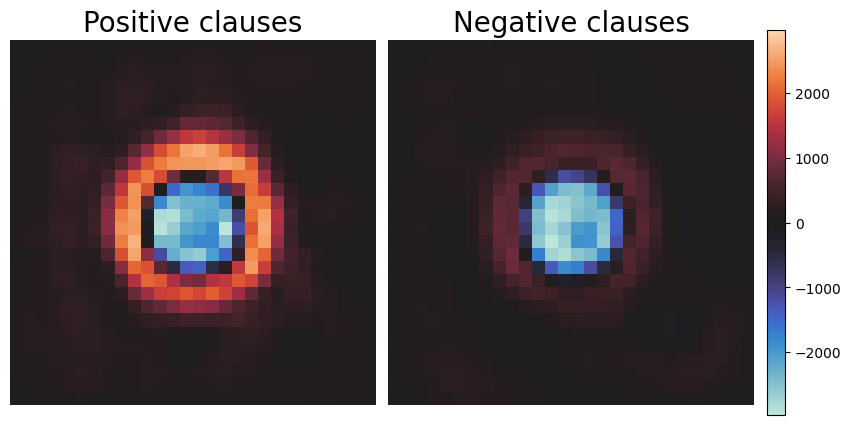

pos shape: (28, 28), min: -2968.08, max: 2670.82
neg shape: (28, 28), min: -2970.95, max: 916.54
saved_heatmaps/adaptive_gaussian/blood_adaptive_gaussian_gh_c7.svg


In [21]:
target_class = 7
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)